## Importing the dependencies

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

## Loading and Preprocessing Datasets

In [45]:
hydro = pd.read_csv('US_Geo_Hydro.csv')
solar = pd.read_csv('US_Solar.csv')
wind = pd.read_csv('US_Wind.csv')

In [46]:

for df in (hydro, solar, wind):
    df.rename(columns={
        'area_developable_sq_km': 'area',
        'capacity_ac_mw'        : 'capacity'
    }, inplace=True)

# Tag each with its energy type
hydro['energy_type'] = 'Hydro'
solar['energy_type'] = 'Solar'
wind ['energy_type'] = 'Wind'

# Combine
combined_df = pd.concat([hydro, solar, wind], ignore_index=True).dropna(subset=['latitude','longitude','area','capacity'])

print(combined_df[['energy_type','latitude','longitude','area','capacity']].head())


  energy_type   latitude   longitude       area   capacity
0       Hydro  48.856865 -105.555569   5.633064  13.353907
1       Hydro  48.866631 -105.390266  30.681261  73.433174
2       Hydro  48.876228 -105.224905   5.100894  12.053098
3       Hydro  48.978116 -103.236463   0.025515   0.059774
4       Hydro  48.999749 -102.738285   0.002025   0.004813


/tmp/ipykernel_1134/78036993.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


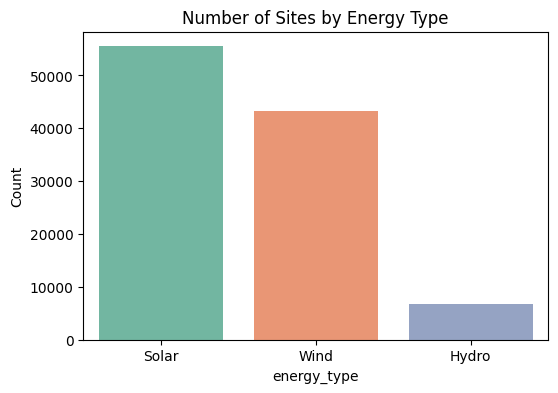

In [47]:
plt.figure(figsize=(6,4))
sns.countplot(
    data=combined_df,
    x='energy_type',
    order=combined_df['energy_type'].value_counts().index,
    palette='Set2'
)
plt.title("Number of Sites by Energy Type")
plt.ylabel("Count")
plt.show()


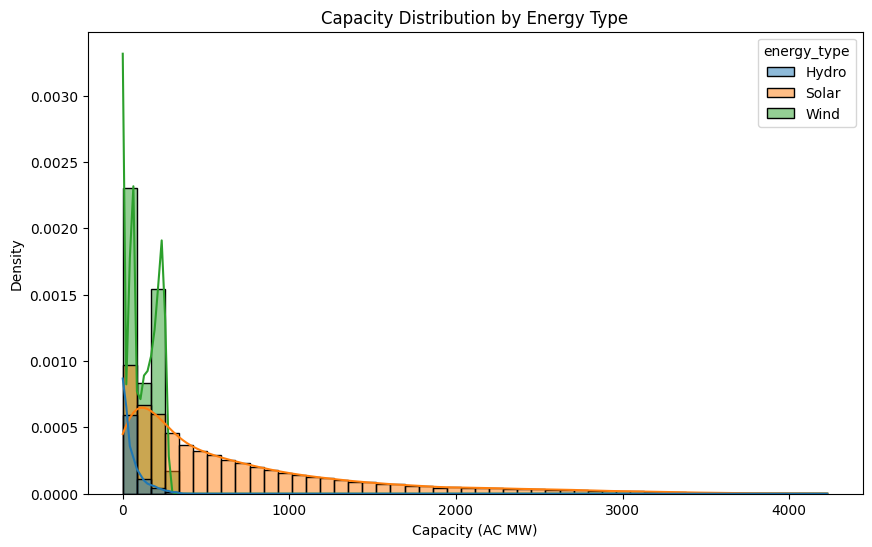

In [48]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=combined_df,
    x='capacity',
    hue='energy_type',
    bins=50, kde=True, stat='density'
)
plt.title("Capacity Distribution by Energy Type")
plt.xlabel("Capacity (AC MW)")
plt.ylabel("Density")
plt.show()


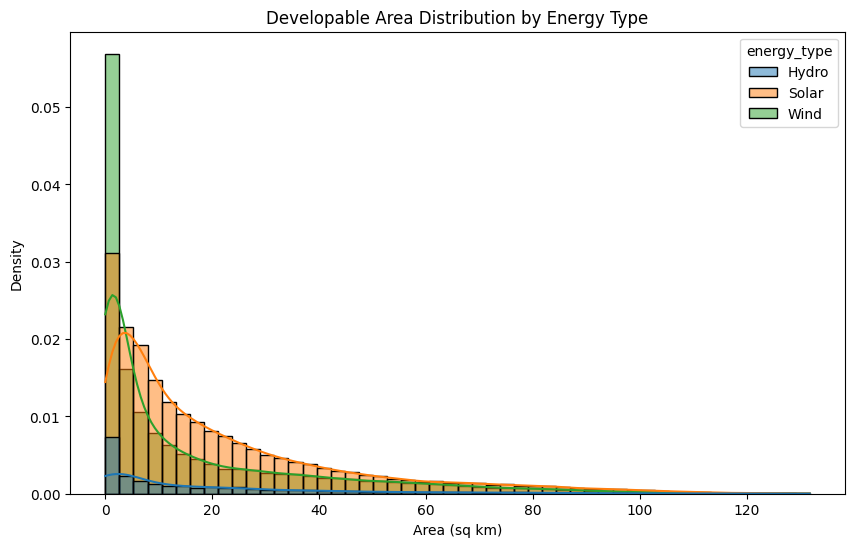

In [49]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=combined_df,
    x='area',
    hue='energy_type',
    bins=50, kde=True, stat='density'
)
plt.title("Developable Area Distribution by Energy Type")
plt.xlabel("Area (sq km)")
plt.ylabel("Density")
plt.show()


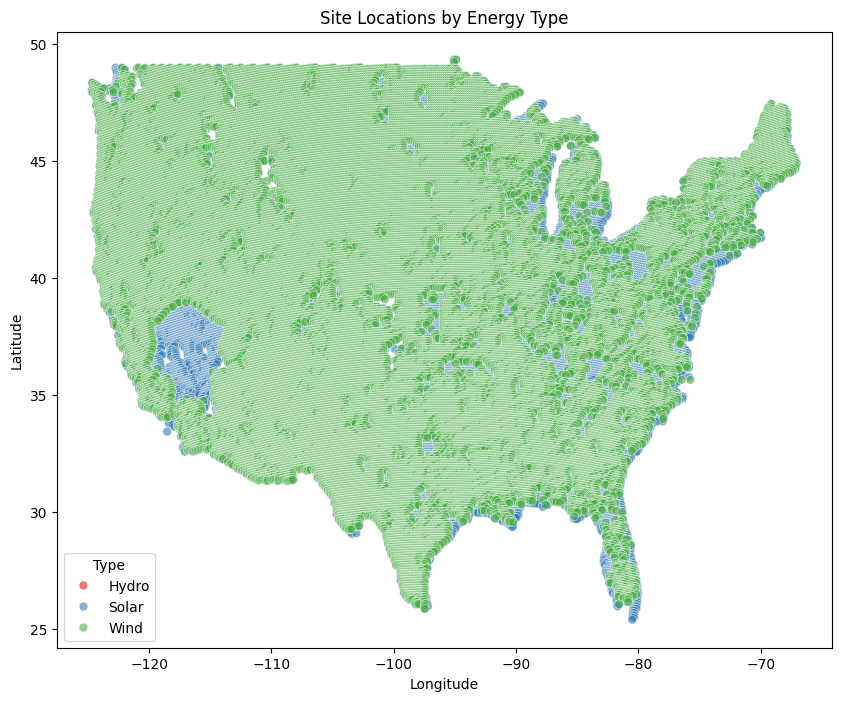

In [50]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=combined_df,
    x='longitude', y='latitude',
    hue='energy_type',
    palette='Set1', alpha=0.6, s=40
)
plt.title("Site Locations by Energy Type")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Type")
plt.show()


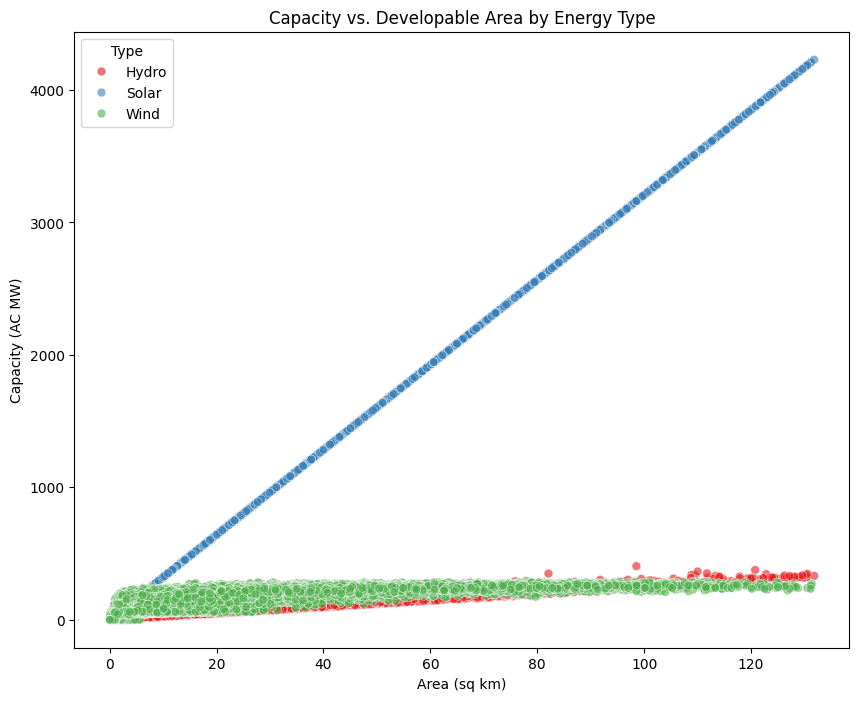

In [51]:
plt.figure(figsize=(10,8))
sns.scatterplot(
    data=combined_df,
    x='area', y='capacity',
    hue='energy_type',
    palette='Set1',
    alpha=0.6, s=40
)
plt.title("Capacity vs. Developable Area by Energy Type")
plt.xlabel("Area (sq km)")
plt.ylabel("Capacity (AC MW)")
plt.legend(title="Type")
plt.show()


As the solar coverage area increases, the throughput will also increase as the linear relation shows.
This is not the case for hydro and wind.

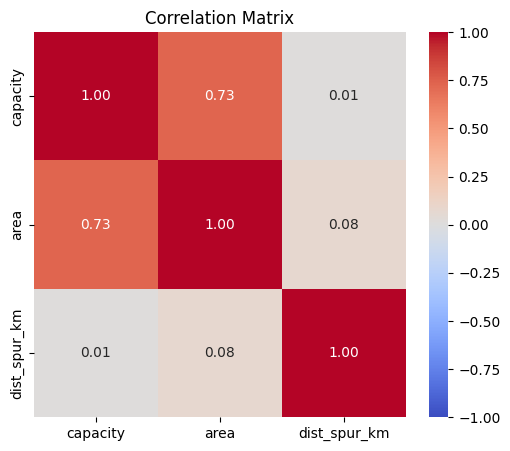

In [52]:
num_cols = ['capacity','area','dist_spur_km']
corr_df = combined_df[num_cols].dropna().corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_df, annot=True, cmap='coolwarm', fmt=".2f",
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix")
plt.show()


The coorelation between area and capacity could be affected by solar energy.

### Upsampling and Balancing data

In [53]:
target_rows = 60000

def upsample_df(df, target_rows):
    if len(df) >= target_rows:
        return df.sample(target_rows, replace=False, random_state=42).reset_index(drop=True)
    else:
        return df.sample(target_rows, replace=True, random_state=42).reset_index(drop=True)

# Apply upsampling
hydro_upsampled = upsample_df(hydro, target_rows)
solar_upsampled = upsample_df(solar, target_rows)
wind_upsampled = upsample_df(wind, target_rows)

# Save the new datasets
#hydro_upsampled.to_csv("USHydro.csv", index=False)
#solar_upsampled.to_csv("USSolar.csv", index=False)
#wind_upsampled.to_csv("USWind.csv", index=False)

# Print confirmation
print("Upsampled datasets:")
print("Hydro:", hydro_upsampled.shape)
print("Solar:", solar_upsampled.shape)
print("Wind:", wind_upsampled.shape)


Upsampled datasets:
Hydro: (60000, 8)
Solar: (60000, 11)
Wind: (60000, 12)


## Combining Datasets

In [54]:
# -------------------------------
# 1. Add Energy Type Identifiers
# -------------------------------
hydro_upsampled['energy_type'] = 'Hydro'
solar_upsampled['energy_type'] = 'Solar'
wind_upsampled['energy_type'] = 'Wind'

# -------------------------------
# 2. Normalize Column Names
# -------------------------------
for df in [hydro_upsampled, solar_upsampled, wind_upsampled]:
    # Standardize 'capacity' column
    if 'capacity_ac_mw' in df.columns:
        df['capacity'] = df['capacity_ac_mw']
        df.drop(columns=['capacity_ac_mw'], inplace=True)
    # Else, assume 'capacity' column is already correct

    # Standardize 'area' column
    if 'area_developable_sq_km' in df.columns:
        df['area'] = df['area_developable_sq_km']
        df.drop(columns=['area_developable_sq_km'], inplace=True)
    elif 'area' not in df.columns: # Fallback if 'area' column is somehow missing
        df['area'] = 0

# -------------------------------
# 3. Add Elevation and Resource Columns (Fill with 0 if missing)
# -------------------------------

hydro_upsampled['elevation_m'] = 0
hydro_upsampled['resource'] = 0

# For solar and wind, add elevation/resource if missing
for df in [solar_upsampled, wind_upsampled]:
    if 'elevation_m' not in df.columns:
        df['elevation_m'] = 0
    else:
        df['elevation_m'].fillna(0, inplace=True)

    if 'resource' not in df.columns:
        df['resource'] = 0
    else:
        df['resource'].fillna(0, inplace=True)

# -------------------------------
# 4. Assign Unique Identifiers
# -------------------------------
for df in [hydro_upsampled, solar_upsampled, wind_upsampled]:
    if 'sc_point_gid' not in df.columns:
        df['sc_point_gid'] = df.index

# -------------------------------
# 5. Define Common Columns
# -------------------------------
common_cols = [
    'sc_point_gid', 'latitude', 'longitude',
    'capacity', 'area', 'energy_type',
    'elevation_m', 'resource'
]

# -------------------------------
# 6. Combine Datasets
# -------------------------------
combined_df = pd.concat([
    hydro_upsampled[common_cols],
    solar_upsampled[common_cols],
    wind_upsampled[common_cols]
], axis=0, ignore_index=True)

# -------------------------------
# 7. Shuffle Dataset
# -------------------------------
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nSample of combined dataset:")
combined_df.head()


Sample of combined dataset:


/tmp/ipykernel_1134/2321604691.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['elevation_m'].fillna(0, inplace=True)
/tmp/ipykernel_1134/2321604691.py:42: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,sc_point_gid,latitude,longitude,capacity,area,energy_type,elevation_m,resource
0,67492,33.885790,-91.075710,0.000000,0.198000,Wind,45.5000,6.729780
1,9571,47.556362,-116.187850,0.000000,0.211500,Wind,856.6667,4.956268
2,17508,44.555383,-121.989046,12.706543,4.827708,Hydro,0.0000,0.000000
3,41190,40.601764,-102.431902,0.436447,0.182214,Hydro,0.0000,0.000000
4,31736,43.186130,-95.762040,123.436243,3.846619,Solar,436.1250,4.109127


In [55]:
print("\nEnergy type counts:")
print(combined_df['energy_type'].value_counts())

print("\nMissing values per column:")
print(combined_df.isnull().sum())


Energy type counts:
energy_type
Wind     60000
Hydro    60000
Solar    60000
Name: count, dtype: int64

Missing values per column:
sc_point_gid    0
latitude        0
longitude       0
capacity        0
area            0
energy_type     0
elevation_m     0
resource        0
dtype: int64


In [56]:
print("Combined Dataset Summary Statistics:")
combined_df.describe()

Combined Dataset Summary Statistics:


,sc_point_gid,latitude,longitude,capacity,area,elevation_m,resource
count,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000
mean,46325.141056,38.692883,-102.697717,290.501413,19.668666,530.450186,3.785063
std,21934.761920,5.445864,12.477974,527.988952,23.852724,676.371622,2.929114
min,796.000000,25.487381,-124.662796,0.000000,0.000405,-71.000000,0.000000
25%,28167.750000,33.825464,-112.670760,21.266637,2.117700,0.000000,0.000000
50%,44733.000000,39.071062,-104.249167,102.000000,9.955408,241.183333,4.466247
75%,65638.250000,43.019478,-94.192930,246.000000,28.635302,856.694469,6.036443
max,98222.000000,49.332330,-67.070724,4208.739787,131.798137,3131.000000,12.130080


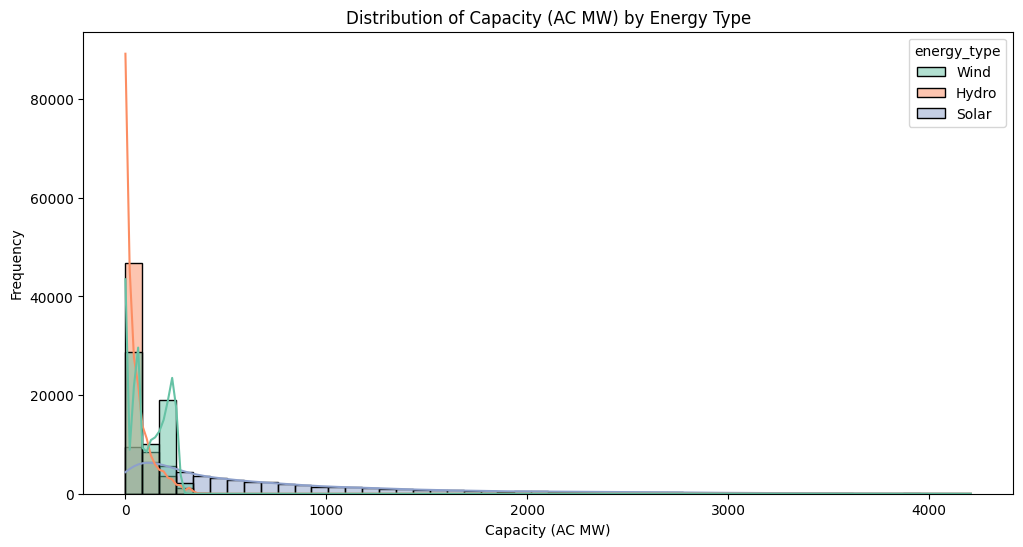

In [57]:
plt.figure(figsize=(12, 6))
sns.histplot(data=combined_df, x='capacity', hue='energy_type', bins=50, kde=True, palette='Set2')
plt.title("Distribution of Capacity (AC MW) by Energy Type")
plt.xlabel("Capacity (AC MW)")
plt.ylabel("Frequency")
plt.show()

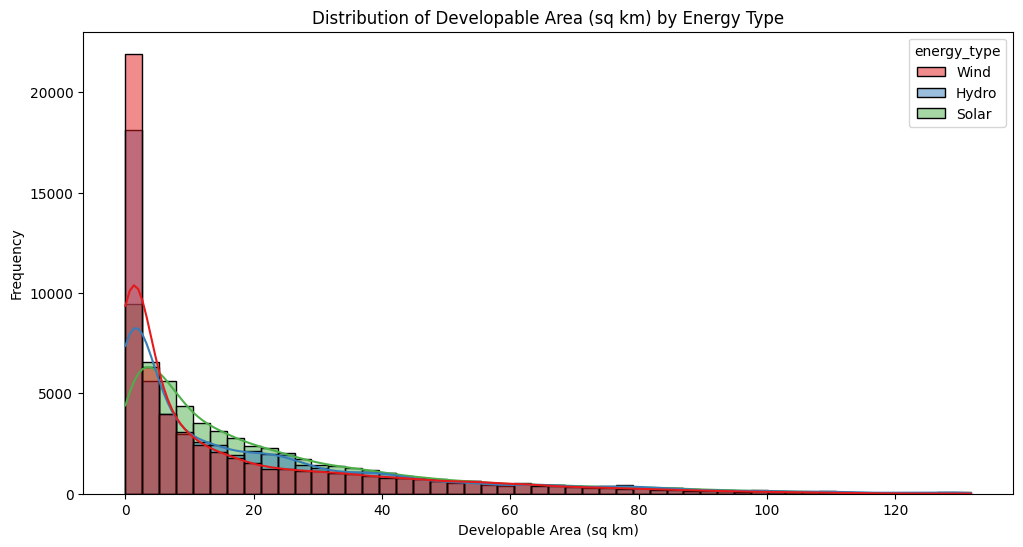

In [58]:
# Plot distribution (histogram) of developable area.
plt.figure(figsize=(12, 6))
sns.histplot(data=combined_df, x='area', hue='energy_type', bins=50, kde=True, palette='Set1')
plt.title("Distribution of Developable Area (sq km) by Energy Type")
plt.xlabel("Developable Area (sq km)")
plt.ylabel("Frequency")
plt.show()

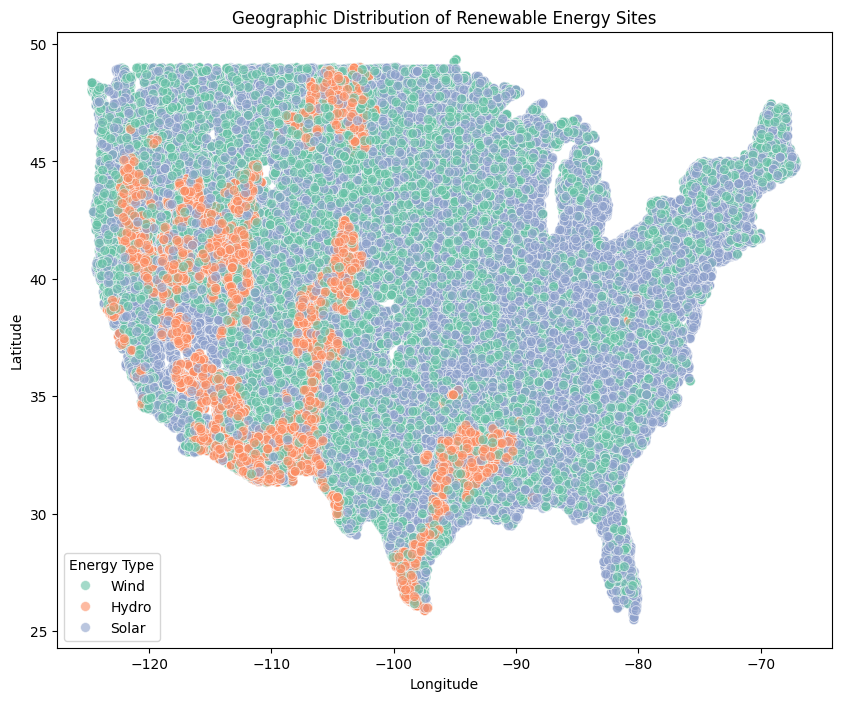

In [59]:
# Scatter plot of renewable energy sites using latitude and longitude.
plt.figure(figsize=(10, 8))
sns.scatterplot(data=combined_df, x='longitude', y='latitude', hue='energy_type', palette='Set2', alpha=0.6, s=50)
plt.title("Geographic Distribution of Renewable Energy Sites")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Energy Type")
plt.show()


Hydro energy is more concentrated in the areas with water bodies, whereas solar and wind are more distributed.

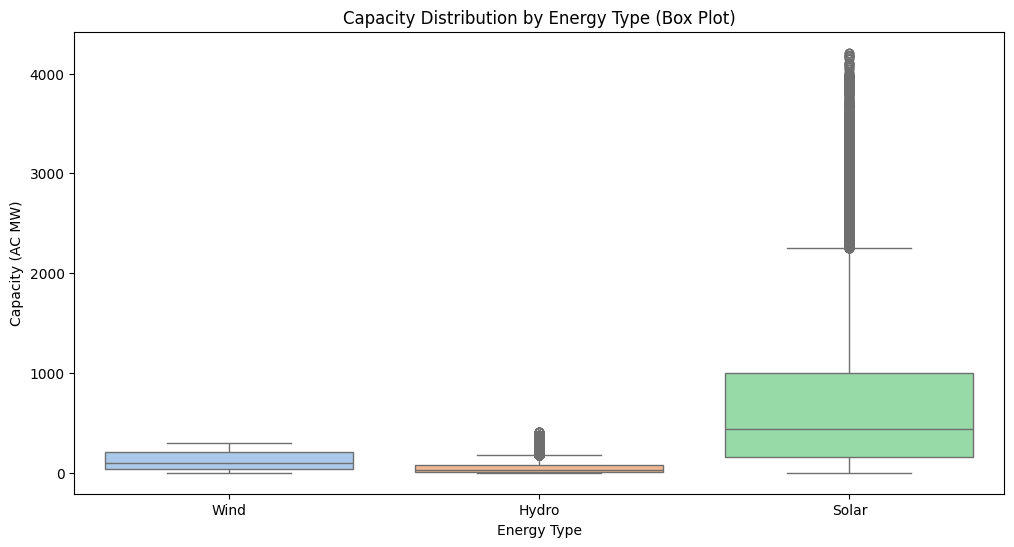

In [60]:
# %% [code]
plt.figure(figsize=(12, 6))
sns.boxplot(data=combined_df, x='energy_type', y='capacity', hue='energy_type', palette='pastel')
plt.title("Capacity Distribution by Energy Type (Box Plot)")
plt.xlabel("Energy Type")
plt.ylabel("Capacity (AC MW)")
plt.show()


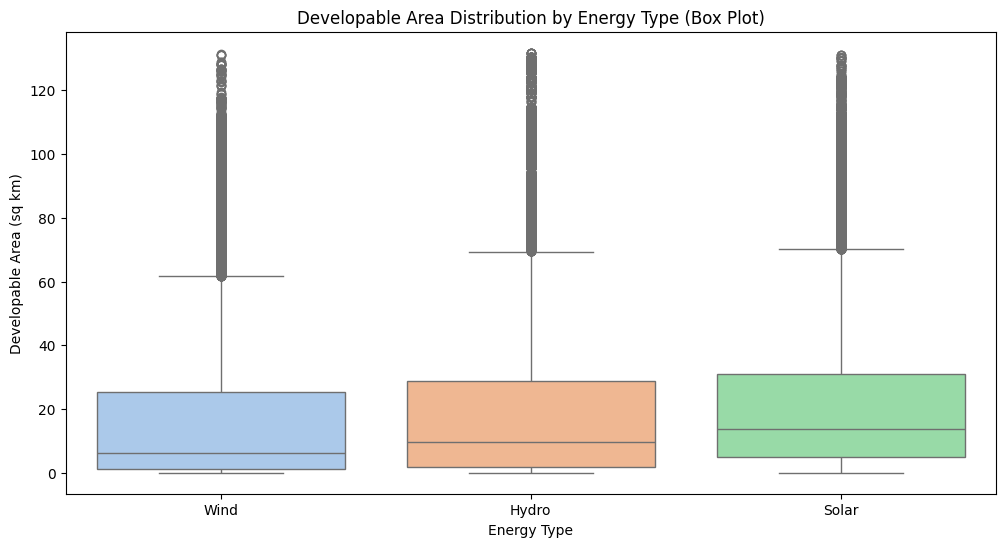

In [61]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=combined_df, x='energy_type', y='area', hue='energy_type',palette='pastel')
plt.title("Developable Area Distribution by Energy Type (Box Plot)")
plt.xlabel("Energy Type")
plt.ylabel("Developable Area (sq km)")
plt.show()

Most of the developable area is between 20 square km.
The outliers can be due to different terrarian, as some might have major solar, wind or hydro plants.

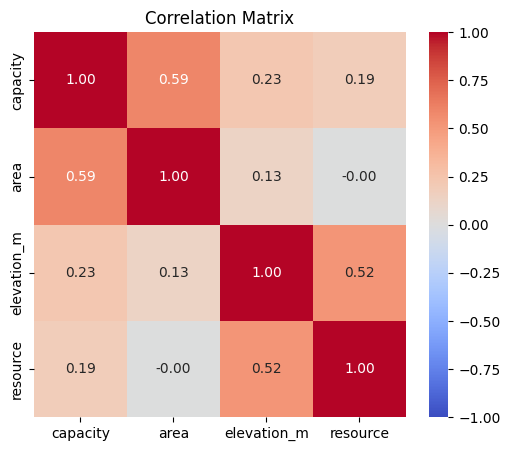

In [62]:

num_cols = ['capacity','area', 'elevation_m', 'resource']
corr_df = combined_df[num_cols].dropna().corr()

plt.figure(figsize=(6,5))
sns.heatmap(
    corr_df, annot=True, cmap='coolwarm', fmt=".2f",
    vmin=-1, vmax=1
)
plt.title("Correlation Matrix")
plt.show()


## Analysis

TOPSIS ranking (top 5 sites):
         latitude   longitude     capacity        area  topsis_score
166676  37.425550 -116.478910  4208.739787  131.156102      0.998166
116093  32.507206 -113.763430  4207.844517  131.128203      0.998076
160651  32.507206 -113.763430  4207.844517  131.128203      0.998076
73282   33.628807 -106.648926  4188.600651  130.528510      0.994272
39743   33.738000 -106.533690  4180.322131  130.270528      0.992373
MOORA ranking (top 5 sites):
         latitude   longitude     capacity        area  moora_score
166676  37.425550 -116.478910  4208.739787  131.156102     0.000063
116093  32.507206 -113.763430  4207.844517  131.128203     0.000063
160651  32.507206 -113.763430  4207.844517  131.128203     0.000063
73282   33.628807 -106.648926  4188.600651  130.528510     0.000063
39743   33.738000 -106.533690  4180.322131  130.270528     0.000063
AHP derived criteria weights: [0.66666667 0.33333333]
Hybrid AHP-TOPSIS ranking (top 5 sites):
         latitude   long

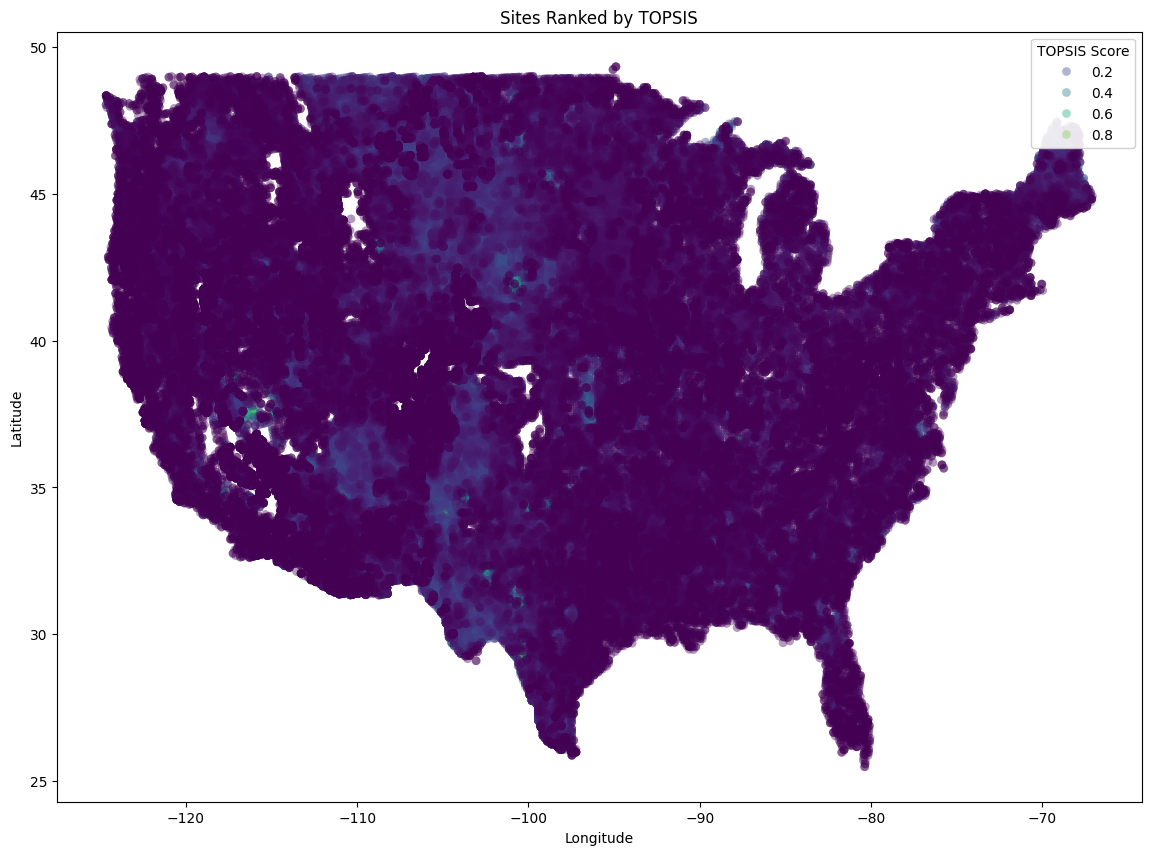

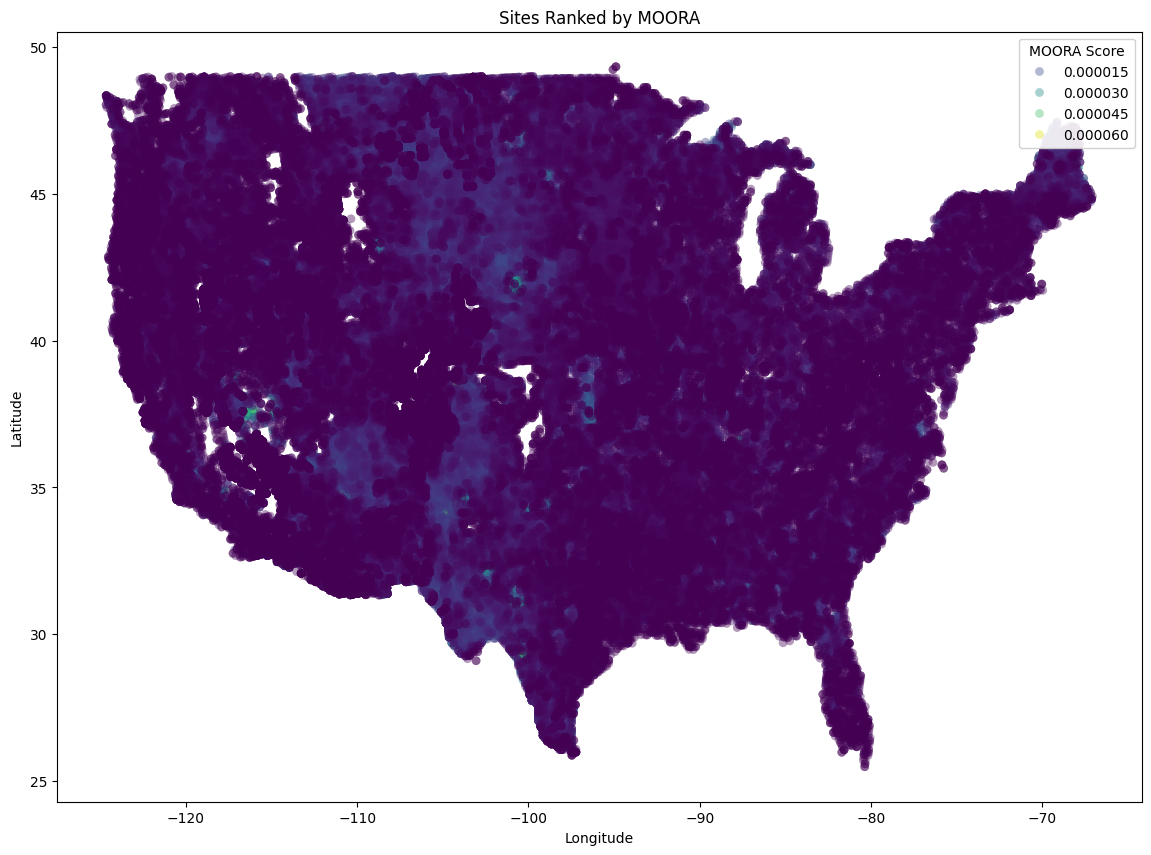

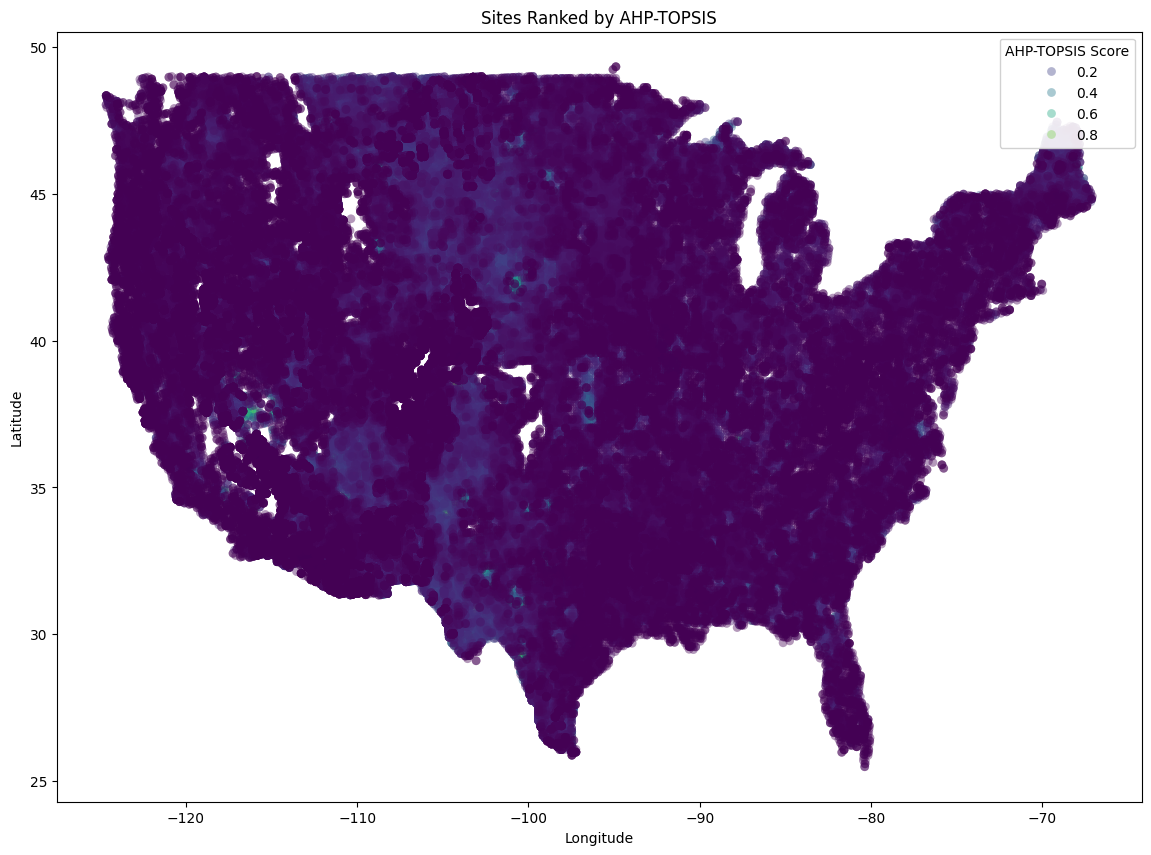

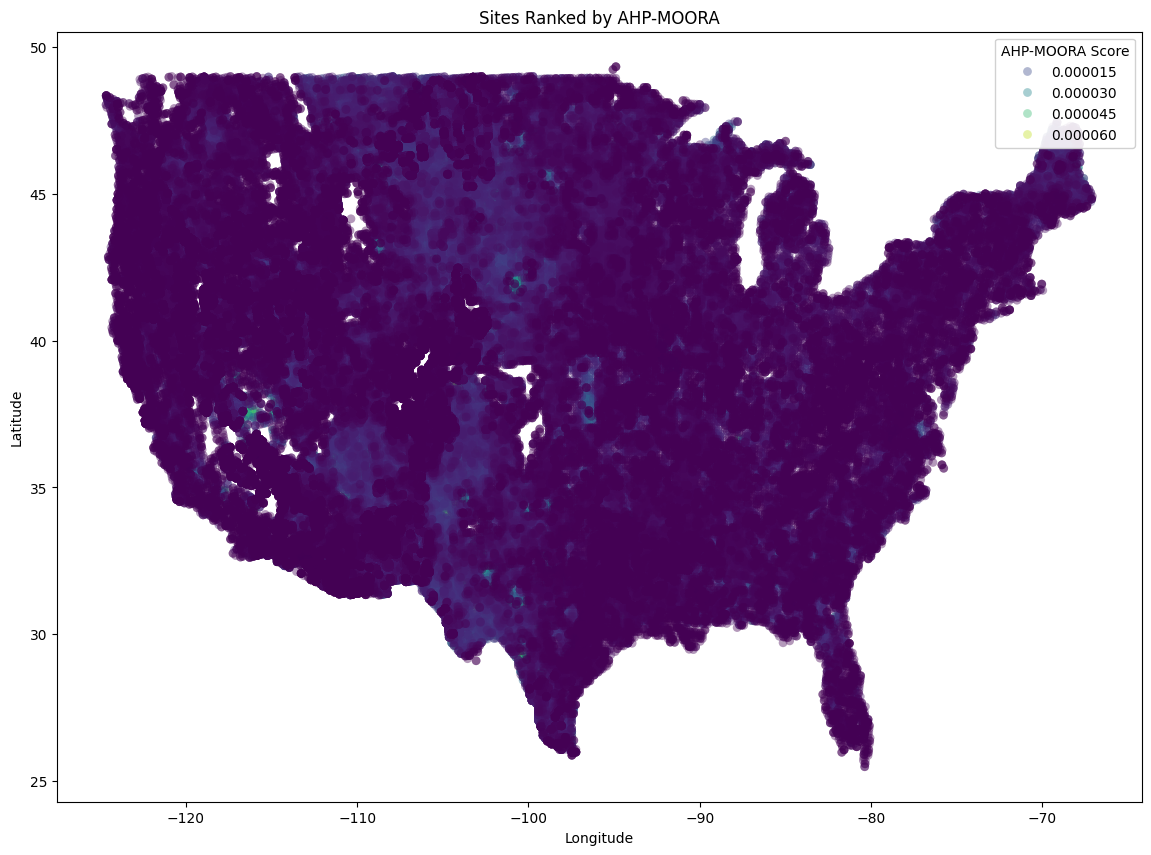

In [63]:
# 1. Define functions

# TOPSIS IMPLEMENTATION
def topsis(decision_matrix, weights, criteria):

    # Normalize the decision matrix using Euclidean norm.
    norm_matrix = decision_matrix.apply(lambda col: col / np.sqrt((col**2).sum()), axis=0)

    # Multiply by weights.
    weighted_matrix = norm_matrix * weights

    # Determine the ideal best and worst.
    ideal_best = {}
    ideal_worst = {}
    for col, crit in zip(weighted_matrix.columns, criteria):
        if crit == 1:  # Beneficial criterion
            ideal_best[col] = weighted_matrix[col].max()
            ideal_worst[col] = weighted_matrix[col].min()
        else:  # Non-beneficial criterion
            ideal_best[col] = weighted_matrix[col].min()
            ideal_worst[col] = weighted_matrix[col].max()

    # Calculate distances from the ideal best and worst.
    diff_best = weighted_matrix - pd.Series(ideal_best)
    diff_worst = weighted_matrix - pd.Series(ideal_worst)
    distance_best = diff_best.pow(2).sum(axis=1).apply(np.sqrt)
    distance_worst = diff_worst.pow(2).sum(axis=1).apply(np.sqrt)

    # Closeness coefficient
    cc = distance_worst / (distance_best + distance_worst)
    return cc


# Considering 'capacity' and 'area' as beneficial criteria.
decision_data = combined_df[['capacity', 'area']]
# We are cosidering weights for capacity and area as 0.6 and 0.4 respectively.
weights = np.array([0.6, 0.4])
# Both criteria are beneficial: 1 means more is better.
criteria = [1, 1]

combined_df['topsis_score'] = topsis(decision_data, weights, criteria)
combined_df.sort_values('topsis_score', ascending=False, inplace=True)
print("TOPSIS ranking (top 5 sites):")
print(combined_df[['latitude', 'longitude', 'capacity', 'area', 'topsis_score']].head())


# MOORA IMPLEMENTATION
def moora(decision_matrix, weights, criteria):

    # Normalize the decision matrix by dividing by the sum of absolute values for each column.
    norm_matrix = decision_matrix / decision_matrix.abs().sum()
    weighted_matrix = norm_matrix * weights

    # For beneficial criteria add the score; for non-beneficial subtract the score.
    beneficial = weighted_matrix.loc[:, [c for c, crit in zip(weighted_matrix.columns, criteria) if crit == 1]]
    non_beneficial = weighted_matrix.loc[:, [c for c, crit in zip(weighted_matrix.columns, criteria) if crit == -1]]

    # When all criteria are beneficial, non_beneficial will be empty.
    score = weighted_matrix.sum(axis=1)
    if not non_beneficial.empty:
        score = beneficial.sum(axis=1) - non_beneficial.sum(axis=1)
    return score

# Considering 'capacity' and 'area' as beneficial criteria.
moora_scores = moora(decision_data, weights, criteria)
combined_df['moora_score'] = moora_scores
combined_df.sort_values('moora_score', ascending=False, inplace=True)
print("MOORA ranking (top 5 sites):")
print(combined_df[['latitude', 'longitude', 'capacity', 'area', 'moora_score']].head())


# HYBRID AHP-TOPSIS AND AHP-MOORA
def ahp_weights(pairwise_matrix):

    eigvals, eigvecs = np.linalg.eig(pairwise_matrix)
    max_index = np.argmax(eigvals.real)
    weights = np.abs(eigvecs[:, max_index].real)
    return weights / weights.sum()

# AHP weights for criteria: here we assume a pairwise comparison matrix.
# We are assuming that 'capacity' is twice as important as 'area'.
pairwise = np.array([[1,    2],
                     [1/2,  1]])
criteria_weights = ahp_weights(pairwise)
print("AHP derived criteria weights:", criteria_weights)

# Using the weights from AHP for TOPSIS and MOORA
# --- AHP-TOPSIS scoring ---
combined_df['ahp_topsis_score'] = topsis(decision_data, criteria_weights, [1, 1])
combined_df.sort_values('ahp_topsis_score', ascending=False, inplace=True)
print("Hybrid AHP-TOPSIS ranking (top 5 sites):")
print(combined_df[['latitude', 'longitude', 'capacity', 'area', 'ahp_topsis_score']].head())
print("\n")
# --- AHP-MOORA scoring ---
combined_df['ahp_moora_score'] = moora(decision_data, criteria_weights, criteria)
combined_df.sort_values('ahp_moora_score', ascending=False, inplace=True)
print("AHP-MOORA ranking (top 5 sites):")
print(combined_df[['latitude', 'longitude', 'capacity', 'area', 'ahp_moora_score']].head())


# 2. Prepare data & parameters
decision_data = combined_df[['capacity','area']]
criteria = [1,1]
weights     = np.array([0.6,0.4])

# 3. Compute plain scores
combined_df['topsis_score'] = topsis(decision_data, weights, criteria)
combined_df['moora_score']  = moora(decision_data, weights, criteria)

# 4. Derive AHP weights & compute hybrid scores
pairwise = np.array([[1,2],[1/2,1]])
ahp_wts  = ahp_weights(pairwise)
combined_df['ahp_topsis_score'] = topsis(decision_data, ahp_wts, criteria)
combined_df['ahp_moora_score']  = moora(decision_data, ahp_wts, criteria)

# 5. Print top-5 for each (sorting only for display)
print("TOPSIS top-5:")
print(combined_df.sort_values('topsis_score', ascending=False)
               [['latitude','longitude','topsis_score']].head())

print("\nMOORA top-5:")
print(combined_df.sort_values('moora_score', ascending=False)
               [['latitude','longitude','moora_score']].head())

print("\nAHP-TOPSIS top-5:")
print(combined_df.sort_values('ahp_topsis_score', ascending=False)
               [['latitude','longitude','ahp_topsis_score']].head())

print("\nAHP-MOORA top-5:")
print(combined_df.sort_values('ahp_moora_score', ascending=False)
               [['latitude','longitude','ahp_moora_score']].head())

# 6. Plot all four maps in sequence
import matplotlib.pyplot as plt
import seaborn as sns

for score_col, title in [
    ('topsis_score',      'TOPSIS'),
    ('moora_score',       'MOORA'),
    ('ahp_topsis_score',  'AHP-TOPSIS'),
    ('ahp_moora_score',   'AHP-MOORA')
]:
    plt.figure(figsize=(14,10))
    sns.scatterplot(
        data=combined_df,
        x='longitude', y='latitude',
        hue=score_col,
        palette='viridis',
        s=40, alpha=0.4, linewidth=0
    )
    plt.title(f"Sites Ranked by {title}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend(title=f'{title} Score', loc='upper right', framealpha=0.9)
    plt.show()


## Encoding and Scaling

In [64]:
# Select features and target for renewable type classification.
X_type = combined_df[['latitude', 'longitude', 'area', 'elevation_m', 'resource']].values
y_type = combined_df['energy_type'].values

# Encode the string labels into numbers.
label_encoder = LabelEncoder()
y_type_enc = label_encoder.fit_transform(y_type)
print("Encoded energy types:", np.unique(y_type_enc))

# Split dataset.
X_train_type, X_test_type, y_train_type, y_test_type = train_test_split(X_type, y_type_enc, test_size=0.2, random_state=42)

# Scale the features.
scaler_type = StandardScaler()
X_train_type_scaled = scaler_type.fit_transform(X_train_type)
X_test_type_scaled = scaler_type.transform(X_test_type)


Encoded energy types: [0 1 2]


# Classification

### By Source Type

1. Logistic Regression -

Logistic Regression Accuracy: 0.9460277777777778


<Axes: >

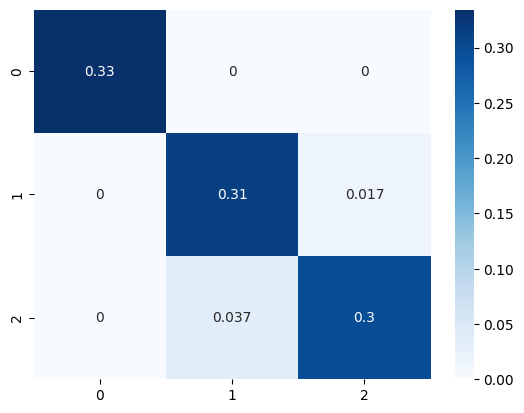

In [65]:

from sklearn.linear_model import LogisticRegression

model_logreg = LogisticRegression(max_iter=1000)
model_logreg.fit(X_train_type_scaled, y_train_type)

y_pred_logreg = model_logreg.predict(X_test_type_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test_type, y_pred_logreg))
cf_type_log = confusion_matrix(y_test_type, y_pred_logreg)
sns.heatmap(cf_type_log/np.sum(cf_type_log), annot=True, cmap='Blues')


Decision Tree Classifier Accuracy: 0.9934166666666666


<Axes: >

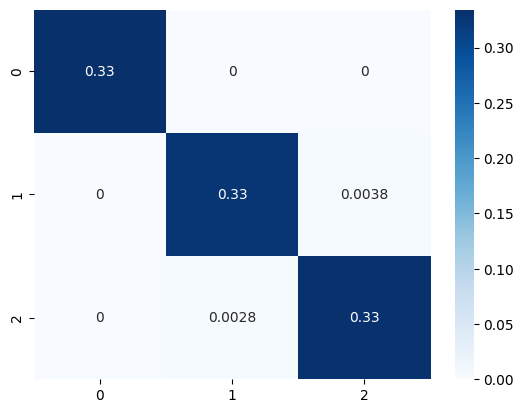

In [66]:

from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_type_scaled, y_train_type)

y_pred_dt = model_dt.predict(X_test_type_scaled)

print("Decision Tree Classifier Accuracy:", accuracy_score(y_test_type, y_pred_dt))

cf_type_dt = confusion_matrix(y_test_type, y_pred_dt)
sns.heatmap(cf_type_dt/np.sum(cf_type_dt), annot=True, cmap='Blues')


Random Forest Classifier Accuracy: 0.9962777777777778


<Axes: >

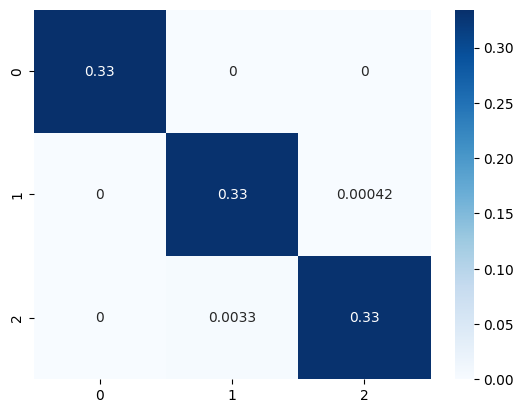

In [67]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_type_scaled, y_train_type)

y_pred_rf = model_rf.predict(X_test_type_scaled)

print("Random Forest Classifier Accuracy:", accuracy_score(y_test_type, y_pred_rf))

cf_type_rf = confusion_matrix(y_test_type, y_pred_rf)
sns.heatmap(cf_type_rf/np.sum(cf_type_rf), annot=True, cmap='Blues')


SVM Classifier Accuracy: 0.96475


<Axes: >

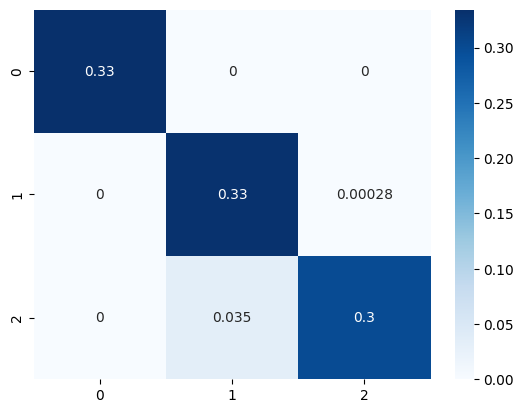

In [68]:
from sklearn.svm import SVC


model_svm = SVC(kernel='rbf', random_state=42)
model_svm.fit(X_train_type_scaled, y_train_type)

y_pred_svm = model_svm.predict(X_test_type_scaled)

print("SVM Classifier Accuracy:", accuracy_score(y_test_type, y_pred_svm))

cf_type_svm = confusion_matrix(y_test_type, y_pred_svm)
sns.heatmap(cf_type_svm/np.sum(cf_type_svm), annot=True, cmap='Blues')

KNN Classifier Accuracy: 0.9825555555555555


Text(0.5, 1.0, 'KNN Confusion Matrix (Normalized)')

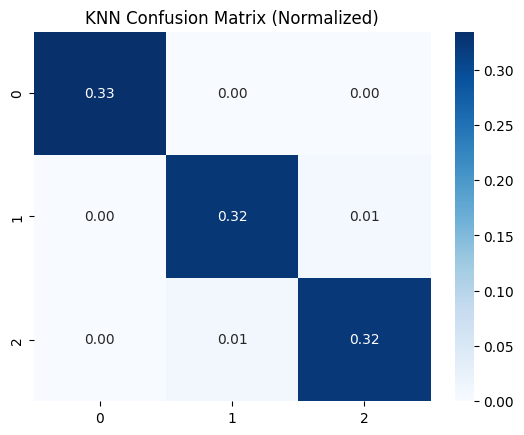

In [69]:

from sklearn.neighbors import KNeighborsClassifier

model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train_type_scaled, y_train_type)

y_pred_knn = model_knn.predict(X_test_type_scaled)

print("KNN Classifier Accuracy:", accuracy_score(y_test_type, y_pred_knn))

cf_type_knn = confusion_matrix(y_test_type, y_pred_knn)
sns.heatmap(cf_type_knn / np.sum(cf_type_knn), annot=True, cmap='Blues', fmt='.2f')
plt.title("KNN Confusion Matrix (Normalized)")


6. LSTM

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,443 (21.26 KB)

 Trainable params: 5,443 (21.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9549 - loss: 0.1153 - val_accuracy: 0.9807 - val_loss: 0.0530
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9812 - loss: 0.0531 - val_accuracy: 0.9817 - val_loss: 0.0493
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9822 - loss: 0.0497 - val_accuracy: 0.9838 - val_loss: 0.0449
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9833 - loss: 0.0472 - val_accuracy: 0.9849 - val_loss: 0.0432
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9835 - loss: 0.0458 - val_accuracy: 0.9800 - val_loss: 0.0511
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9840 - loss: 0.0443 - val_accuracy: 0.9835 - val_loss: 0.0442
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9844 - loss: 0.0433 - val_accuracy: 0.9865 - val_loss: 0.0390
Epoch 8/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9850 - loss: 0

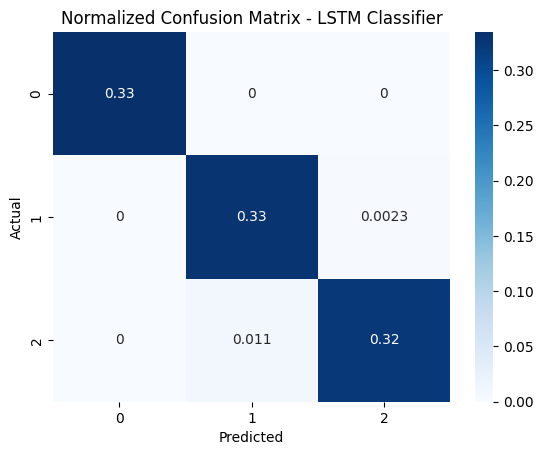

In [70]:
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Reshape the scaled input data for LSTM ---
X_train_lstm = X_train_type_scaled.reshape((X_train_type_scaled.shape[0], 1, X_train_type_scaled.shape[1]))
X_test_lstm = X_test_type_scaled.reshape((X_test_type_scaled.shape[0], 1, X_test_type_scaled.shape[1]))

# --- Convert labels to categorical for softmax ---
y_train_lstm = to_categorical(y_train_type, num_classes=3)
y_test_lstm = to_categorical(y_test_type, num_classes=3)

# --- Build the LSTM Classifier ---
model_lstm = Sequential([
    LSTM(32, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')  # 3 classes
])

model_lstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm.summary()

# --- Train the model ---
history_lstm = model_lstm.fit(X_train_lstm, y_train_lstm, epochs=20,
                              validation_data=(X_test_lstm, y_test_lstm), verbose=1)


y_pred_probs = model_lstm.predict(X_test_lstm)
y_pred_lstm = np.argmax(y_pred_probs, axis=1)
y_true_lstm = np.argmax(y_test_lstm, axis=1)

# --- Accuracy and Confusion Matrix ---
print("LSTM Classifier Accuracy:", accuracy_score(y_true_lstm, y_pred_lstm))

cf_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
sns.heatmap(cf_lstm / np.sum(cf_lstm), annot=True, cmap='Blues')
plt.title("Normalized Confusion Matrix - LSTM Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


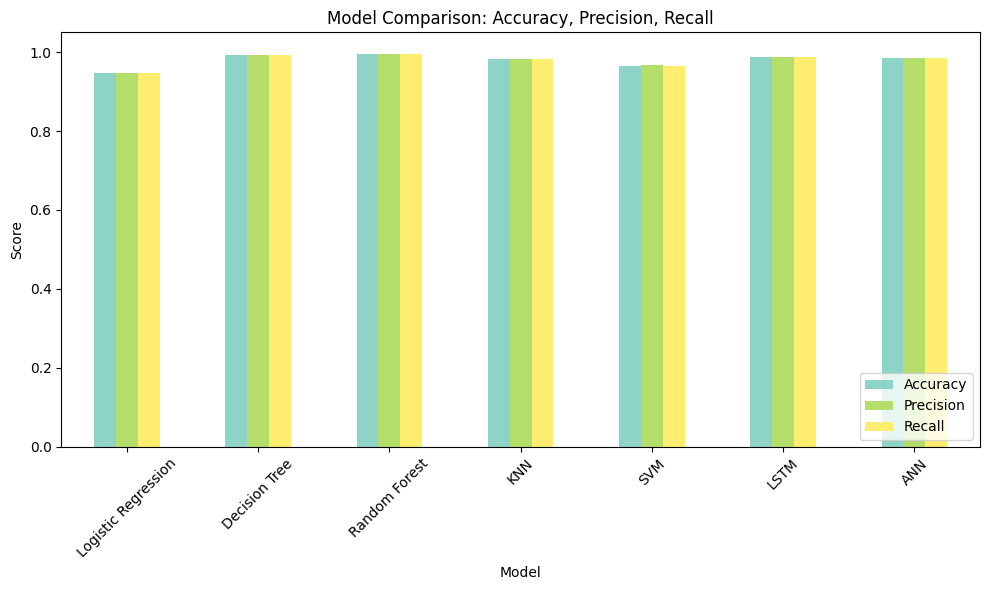

In [111]:
import numpy as np

# Calculate metrics
metrics = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM', 'LSTM', 'ANN'],
    'Accuracy': [
        accuracy_score(y_test_type, y_pred_logreg),
        accuracy_score(y_test_type, y_pred_dt),
        accuracy_score(y_test_type, y_pred_rf),
        accuracy_score(y_test_type, y_pred_knn),
        accuracy_score(y_test_type, y_pred_svm),
        accuracy_score(y_test_type, y_pred_lstm),
        accuracy_score(y_true_ann, y_pred_ann) # ANN accuracy
    ],
    'Precision': [
        precision_score(y_test_type, y_pred_logreg, average='weighted'),
        precision_score(y_test_type, y_pred_dt, average='weighted'),
        precision_score(y_test_type, y_pred_rf, average='weighted'),
        precision_score(y_test_type, y_pred_knn, average='weighted'),
        precision_score(y_test_type, y_pred_svm, average='weighted'),
        precision_score(y_test_type, y_pred_lstm, average='weighted'),
        precision_score(y_true_ann, y_pred_ann, average='weighted') # ANN precision
    ],
    'Recall': [
        recall_score(y_test_type, y_pred_logreg, average='weighted'),
        recall_score(y_test_type, y_pred_dt, average='weighted'),
        recall_score(y_test_type, y_pred_rf, average='weighted'),
        recall_score(y_test_type, y_pred_knn, average='weighted'),
        recall_score(y_test_type, y_pred_svm, average='weighted'),
        recall_score(y_test_type, y_pred_lstm, average='weighted'),
        recall_score(y_true_ann, y_pred_ann, average='weighted') # ANN recall
    ]
}

# Create DataFrame for plotting
metrics_df = pd.DataFrame(metrics)
metrics_df.set_index('Model', inplace=True)

# Plot
metrics_df.plot(kind='bar', figsize=(10,6), colormap='Set3')
plt.title("Model Comparison: Accuracy, Precision, Recall")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45) # Rotate labels for better readability with more models
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Artificial Neural Network (ANN) for Energy Type Classification

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure y_train_type and y_test_type are one-hot encoded for Keras classifier
# They were already encoded as y_train_lstm and y_test_lstm in the previous LSTM cell
# If that cell is not run, we need to re-encode them here.
# Let's assume y_train_type and y_test_type are still label encoded (0, 1, 2)

num_classes_type = len(np.unique(y_train_type))
y_train_type_onehot = to_categorical(y_train_type, num_classes=num_classes_type)
y_test_type_onehot = to_categorical(y_test_type, num_classes=num_classes_type)

# Build the ANN model
model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_type_scaled.shape[1],)), # Input layer
    Dense(32, activation='relu'), # Hidden layer
    Dense(num_classes_type, activation='softmax') # Output layer (3 classes for energy type)
])

model_ann.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_ann.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,563 (10.01 KB)

 Trainable params: 2,563 (10.01 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
# Train the ANN model
history_ann = model_ann.fit(X_train_type_scaled, y_train_type_onehot, epochs=20, batch_size=32,
                            validation_data=(X_test_type_scaled, y_test_type_onehot), verbose=1)

Epoch 1/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9671 - loss: 0.0900 - val_accuracy: 0.9742 - val_loss: 0.0624
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9821 - loss: 0.0502 - val_accuracy: 0.9845 - val_loss: 0.0431
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9838 - loss: 0.0465 - val_accuracy: 0.9804 - val_loss: 0.0525
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9843 - loss: 0.0445 - val_accuracy: 0.9857 - val_loss: 0.0396
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9848 - loss: 0.0433 - val_accuracy: 0.9860 - val_loss: 0.0400
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9851 - loss: 0.0425 - val_accuracy: 0.9857 - val_loss: 0.0402
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9851 - loss: 0.0420 - val_accuracy: 0.9853 - val_loss: 0.0403
Epoch 8/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9856 - loss: 0

1125/1125 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
ANN Classifier Accuracy: 0.9854


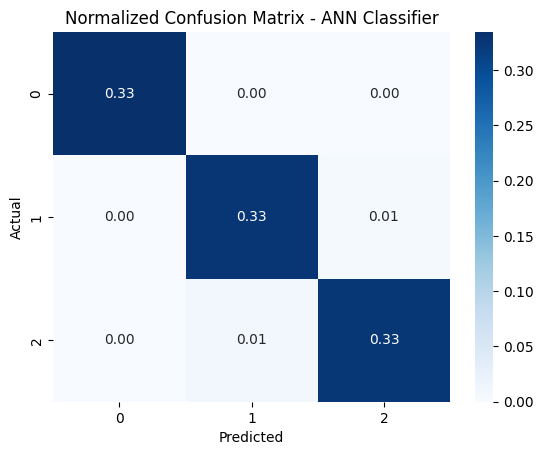

In [74]:
# Predict and evaluate
y_pred_probs_ann = model_ann.predict(X_test_type_scaled)
y_pred_ann = np.argmax(y_pred_probs_ann, axis=1)
y_true_ann = np.argmax(y_test_type_onehot, axis=1) # Convert one-hot back to labels for confusion matrix

# Accuracy
ann_accuracy = accuracy_score(y_true_ann, y_pred_ann)
print(f"ANN Classifier Accuracy: {ann_accuracy:.4f}")

# Confusion Matrix
cf_ann = confusion_matrix(y_true_ann, y_pred_ann)
sns.heatmap(cf_ann / np.sum(cf_ann), annot=True, cmap='Blues', fmt='.2f')
plt.title("Normalized Confusion Matrix - ANN Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

This ANN implementation uses `Dense` layers, where each neuron is connected to every neuron in the previous layer. It's a fundamental neural network structure suitable for learning patterns in tabular data.

### By Potential -

Creating a high_potential column

In [75]:

# For each energy type, assign high potential (1) if capacity is above the median capacity for that type; otherwise, 0.
combined_df['high_potential'] = combined_df.groupby('energy_type')['capacity'].transform(lambda x: (x > x.median()).astype(int))

print("\nHigh Potential counts by Energy Type:")
print(combined_df.groupby('energy_type')['high_potential'].value_counts())



High Potential counts by Energy Type:
energy_type  high_potential
Hydro        0                 30005
             1                 29995
Solar        0                 30001
             1                 29999
Wind         0                 30168
             1                 29832
Name: count, dtype: int64


In [76]:
# One-hot encode the energy_type column.
combined_pot = pd.get_dummies(combined_df, columns=['energy_type'], drop_first=True)

# Define features for potential classification.
feature_cols = ['latitude', 'longitude', 'area', 'elevation_m', 'resource'] + [col for col in combined_pot.columns if col.startswith("energy_type_")]

In [77]:
X_pot = combined_pot[feature_cols].values

# Target column: high_potential (0 or 1)
y_pot = combined_pot['high_potential'].values

print("Features used for potential prediction:", feature_cols)
print("X_pot shape:", X_pot.shape)
print("y_pot value counts:", pd.Series(y_pot).value_counts())

Features used for potential prediction: ['latitude', 'longitude', 'area', 'elevation_m', 'resource', 'energy_type_Solar', 'energy_type_Wind']
X_pot shape: (180000, 7)
y_pot value counts: 0    90174
1    89826
Name: count, dtype: int64


In [78]:
# Split the dataset into train and test sets.
X_train_pot, X_test_pot, y_train_pot, y_test_pot = train_test_split(X_pot, y_pot, test_size=0.2, random_state=42)

# Scale the features.
scaler_pot = StandardScaler()
X_train_pot_scaled = scaler_pot.fit_transform(X_train_pot)
X_test_pot_scaled = scaler_pot.transform(X_test_pot)

print("Train and test splits done for potential prediction.")


Train and test splits done for potential prediction.


1. Logistic Regression

Logistic Regression for Potential Prediction
Accuracy: 0.9642777777777778


<Axes: >

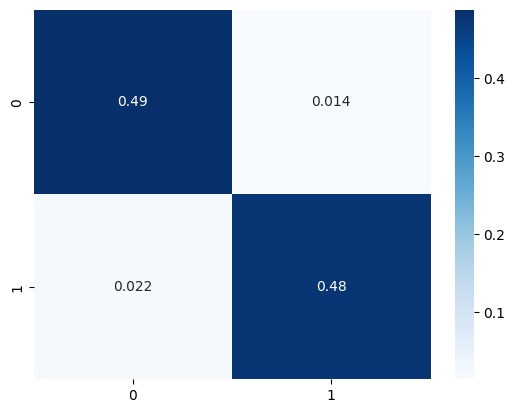

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model_logreg_pot = LogisticRegression(max_iter=1000)
model_logreg_pot.fit(X_train_pot_scaled, y_train_pot)
y_pred_pot_logreg = model_logreg_pot.predict(X_test_pot_scaled)

print("Logistic Regression for Potential Prediction")
print("Accuracy:", accuracy_score(y_test_pot, y_pred_pot_logreg))
cf_pot_log = confusion_matrix(y_test_pot, y_pred_pot_logreg)
sns.heatmap(cf_pot_log/np.sum(cf_pot_log), annot=True, cmap='Blues')


Decision Tree Classifier for Potential Prediction
Accuracy: 0.9885833333333334


<Axes: >

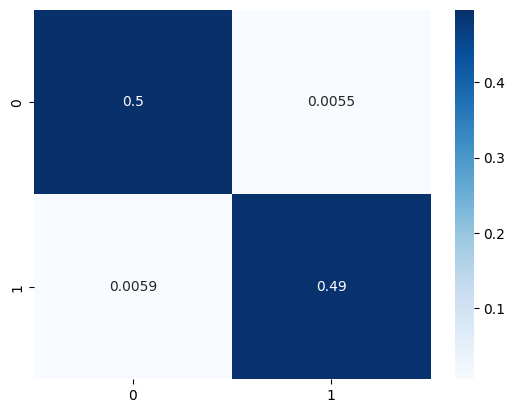

In [80]:
from sklearn.tree import DecisionTreeClassifier

model_dt_pot = DecisionTreeClassifier(random_state=42)
model_dt_pot.fit(X_train_pot_scaled, y_train_pot)
y_pred_pot_dt = model_dt_pot.predict(X_test_pot_scaled)

print("Decision Tree Classifier for Potential Prediction")
print("Accuracy:", accuracy_score(y_test_pot, y_pred_pot_dt))
cf_pot_dt = confusion_matrix(y_test_pot, y_pred_pot_dt)
sns.heatmap(cf_pot_dt/np.sum(cf_pot_dt), annot=True, cmap='Blues')


Random Forest Classifier for Potential Prediction
Accuracy: 0.9917222222222222


<Axes: >

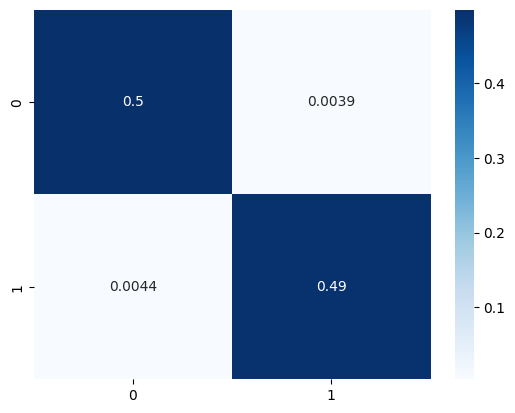

In [81]:
from sklearn.ensemble import RandomForestClassifier

model_rf_pot = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_pot.fit(X_train_pot_scaled, y_train_pot)
y_pred_pot_rf = model_rf_pot.predict(X_test_pot_scaled)

print("Random Forest Classifier for Potential Prediction")
print("Accuracy:", accuracy_score(y_test_pot, y_pred_pot_rf))
cf_pot_rf = confusion_matrix(y_test_pot, y_pred_pot_rf)
sns.heatmap(cf_pot_rf/np.sum(cf_pot_rf), annot=True, cmap='Blues')


SVM Classifier for Potential Prediction
Accuracy: 0.97025


<Axes: >

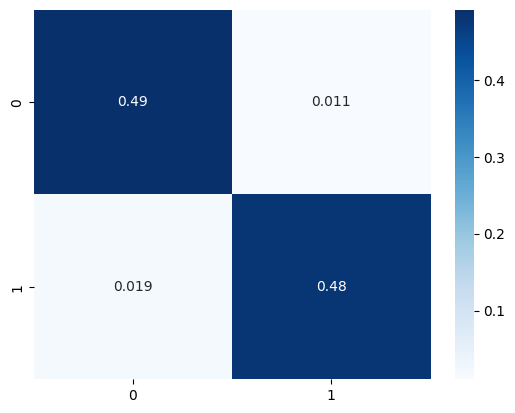

In [82]:
from sklearn.svm import SVC

model_svm_pot = SVC(kernel='rbf', random_state=42)
model_svm_pot.fit(X_train_pot_scaled, y_train_pot)

y_pred_pot_svm = model_svm_pot.predict(X_test_pot_scaled)

print("SVM Classifier for Potential Prediction")
print("Accuracy:", accuracy_score(y_test_pot, y_pred_pot_svm))

cf_pot_svm = confusion_matrix(y_test_pot, y_pred_pot_svm)
sns.heatmap(cf_pot_svm/np.sum(cf_pot_svm), annot=True, cmap='Blues')

Accuracy: 0.9773888888888889


<Axes: >

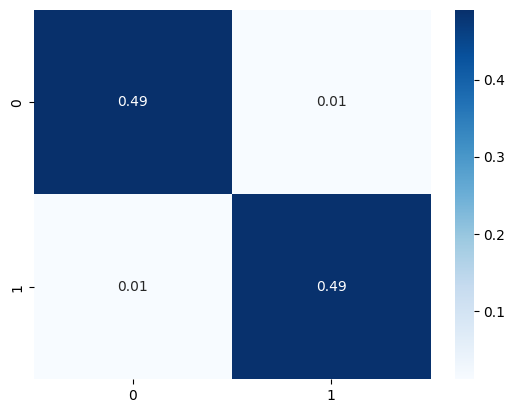

In [83]:
from sklearn.neighbors import KNeighborsClassifier

model_knn_pot = KNeighborsClassifier(n_neighbors=3)
model_knn_pot.fit(X_train_pot_scaled, y_train_pot)

y_pred_pot_knn = model_knn_pot.predict(X_test_pot_scaled)

print("Accuracy:", accuracy_score(y_test_pot, y_pred_pot_knn))

cf_pot_knn = confusion_matrix(y_test_pot, y_pred_pot_knn)
sns.heatmap(cf_pot_knn / np.sum(cf_pot_knn), annot=True, cmap='Blues', fmt='.2f')


6. LSTM

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,682 (22.20 KB)

 Trainable params: 5,682 (22.20 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - accuracy: 0.9572 - loss: 0.1073 - val_accuracy: 0.9669 - val_loss: 0.0798
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9670 - loss: 0.0767 - val_accuracy: 0.9661 - val_loss: 0.0760
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9677 - loss: 0.0744 - val_accuracy: 0.9684 - val_loss: 0.0738
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9676 - loss: 0.0733 - val_accuracy: 0.9694 - val_loss: 0.0723
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9682 - loss: 0.0722 - val_accuracy: 0.9670 - val_loss: 0.0734
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9681 - loss: 0.0714 - val_accuracy: 0.9684 - val_loss: 0.0723
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9685 - loss: 0.0707 - val_accuracy: 0.9696 - val_loss: 0.0699
Epoch 8/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9688 - loss: 0

Text(50.722222222222214, 0.5, 'Actual')

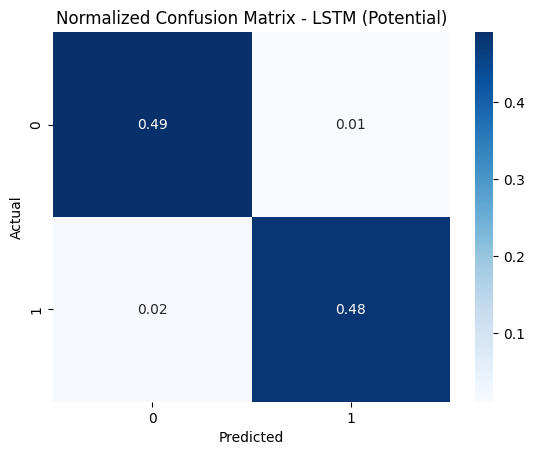

In [84]:

from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix

# --- Reshape the scaled input data for LSTM ---
X_train_lstm = X_train_pot_scaled.reshape((X_train_pot_scaled.shape[0], 1, X_train_pot_scaled.shape[1]))
X_test_lstm = X_test_pot_scaled.reshape((X_test_pot_scaled.shape[0], 1, X_test_pot_scaled.shape[1]))

# --- Convert labels to one-hot encoding ---
num_classes = len(np.unique(y_train_pot))
y_train_lstm = to_categorical(y_train_pot, num_classes=num_classes)
y_test_lstm = to_categorical(y_test_pot, num_classes=num_classes)

# --- Build LSTM model ---
model_lstm_pot = Sequential([
    LSTM(32, activation='relu', input_shape=(1, X_train_pot_scaled.shape[1])),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_lstm_pot.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_lstm_pot.summary()

# --- Train the model ---
history_lstm_pot = model_lstm_pot.fit(X_train_lstm, y_train_lstm, epochs=20,
                                      validation_data=(X_test_lstm, y_test_lstm), verbose=1)

# --- Predict and evaluate ---
y_pred_probs_pot = model_lstm_pot.predict(X_test_lstm)
y_pred_pot_lstm = np.argmax(y_pred_probs_pot, axis=1)
y_true_pot_lstm = np.argmax(y_test_lstm, axis=1)

# --- Accuracy and Confusion Matrix ---
print("LSTM Classifier Accuracy:", accuracy_score(y_true_pot_lstm, y_pred_pot_lstm))

cf_pot_lstm = confusion_matrix(y_true_pot_lstm, y_pred_pot_lstm)
sns.heatmap(cf_pot_lstm / np.sum(cf_pot_lstm), annot=True, cmap='Blues', fmt='.2f')
plt.title("Normalized Confusion Matrix - LSTM (Potential)")
plt.xlabel("Predicted")
plt.ylabel("Actual")


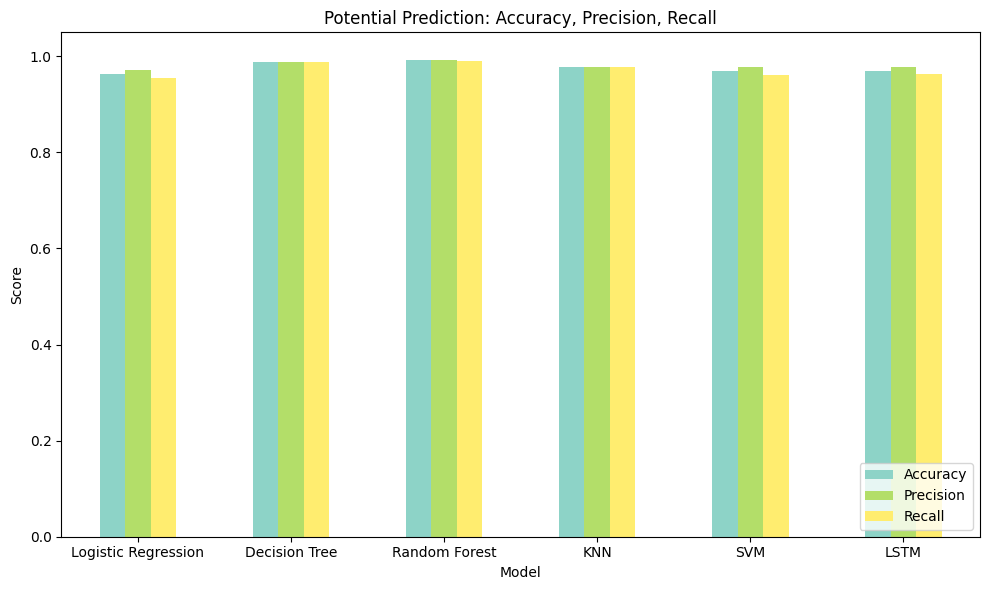

In [85]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
import pandas as pd
import matplotlib.pyplot as plt

metrics_pot = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM', 'LSTM'],
    'Accuracy': [
        accuracy_score(y_test_pot, y_pred_pot_logreg),
        accuracy_score(y_test_pot, y_pred_pot_dt),
        accuracy_score(y_test_pot, y_pred_pot_rf),
        accuracy_score(y_test_pot, y_pred_pot_knn),
        accuracy_score(y_test_pot, y_pred_pot_svm),
        accuracy_score(y_test_pot, y_pred_pot_lstm)
    ],
    'Precision': [
        precision_score(y_test_pot, y_pred_pot_logreg, average='binary'),
        precision_score(y_test_pot, y_pred_pot_dt, average='binary'),
        precision_score(y_test_pot, y_pred_pot_rf, average='binary'),
        precision_score(y_test_pot, y_pred_pot_knn, average='binary'),
        precision_score(y_test_pot, y_pred_pot_svm, average='binary'),
        precision_score(y_test_pot, y_pred_pot_lstm, average='binary')
    ],
    'Recall': [
        recall_score(y_test_pot, y_pred_pot_logreg, average='binary'),
        recall_score(y_test_pot, y_pred_pot_dt, average='binary'),
        recall_score(y_test_pot, y_pred_pot_rf, average='binary'),
        recall_score(y_test_pot, y_pred_pot_knn, average='binary'),
        recall_score(y_test_pot, y_pred_pot_svm, average='binary'),
        recall_score(y_test_pot, y_pred_pot_lstm, average='binary')
    ]
}

# Create DataFrame for plotting
metrics_pot_df = pd.DataFrame(metrics_pot).set_index('Model')

# Plot
metrics_pot_df.plot(kind='bar', figsize=(10, 6), colormap='Set3')
plt.title("Potential Prediction: Accuracy, Precision, Recall")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()


# Regression -

For Generation -

In [86]:
# Select features and target for regression.
X_reg = combined_df[['latitude', 'longitude', 'area', 'elevation_m', 'resource']].values
y_reg = combined_df['capacity'].values

# Split the data.
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# Scale the features.
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

1. Linear

In [87]:
from sklearn.linear_model import LinearRegression

model_lr = LinearRegression()
model_lr.fit(X_train_reg_scaled, y_train_reg)
y_pred_lr = model_lr.predict(X_test_reg_scaled)
print("Linear Regression MSE:", mean_squared_error(y_test_reg, y_pred_lr))
print("Linear Regression R^2:", r2_score(y_test_reg, y_pred_lr))

Linear Regression MSE: 168703.92457057213
Linear Regression R^2: 0.39373407380985004


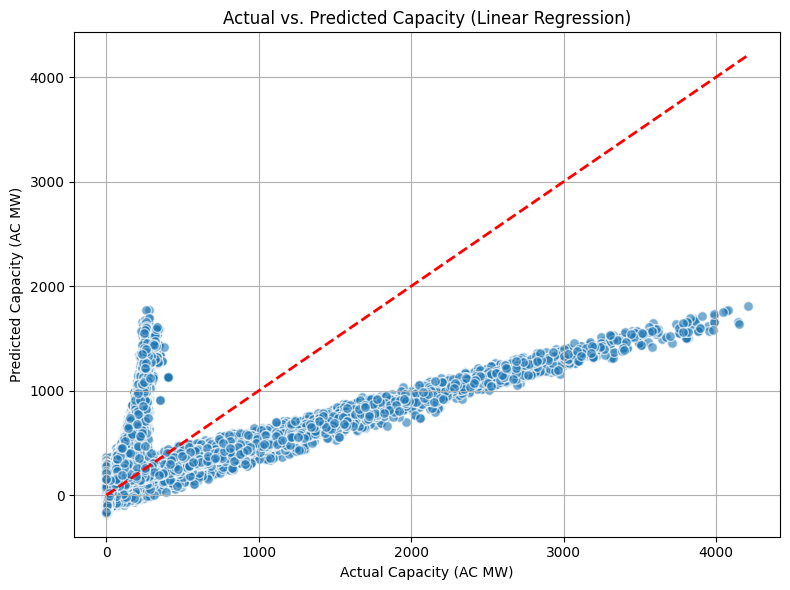

In [88]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_lr, alpha=0.6, edgecolors='w', s=50)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', linewidth=2)
plt.xlabel("Actual Capacity (AC MW)")
plt.ylabel("Predicted Capacity (AC MW)")
plt.title("Actual vs. Predicted Capacity (Linear Regression)")
plt.grid(True)
plt.tight_layout()
plt.show()


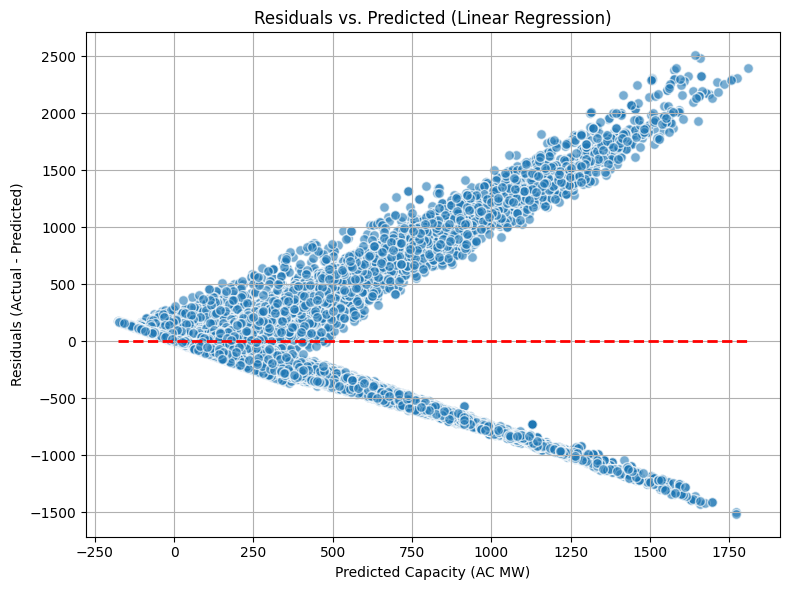

In [89]:
residuals = y_test_reg - y_pred_lr
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lr, residuals, alpha=0.6, edgecolors='w', s=50)
plt.hlines(0, y_pred_lr.min(), y_pred_lr.max(), colors='r', linestyles='--', linewidth=2)
plt.xlabel("Predicted Capacity (AC MW)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted (Linear Regression)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [90]:
from sklearn.tree import DecisionTreeRegressor

model_dt_reg = DecisionTreeRegressor(random_state=42)
model_dt_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_dt_reg = model_dt_reg.predict(X_test_reg_scaled)
print("Decision Tree Regression MSE:", mean_squared_error(y_test_reg, y_pred_dt_reg))
print("Decision Tree Regression R^2:", r2_score(y_test_reg, y_pred_dt_reg))


Decision Tree Regression MSE: 10336.333577439436
Decision Tree Regression R^2: 0.9628546468869179


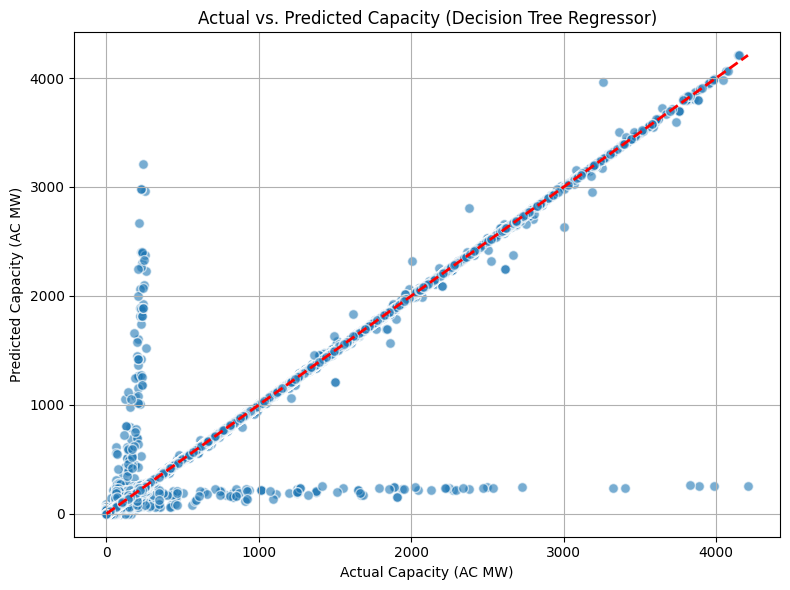

In [91]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_dt_reg, alpha=0.6, edgecolors='w', s=50)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', linewidth=2)
plt.xlabel("Actual Capacity (AC MW)")
plt.ylabel("Predicted Capacity (AC MW)")
plt.title("Actual vs. Predicted Capacity (Decision Tree Regressor)")
plt.grid(True)
plt.tight_layout()
plt.show()

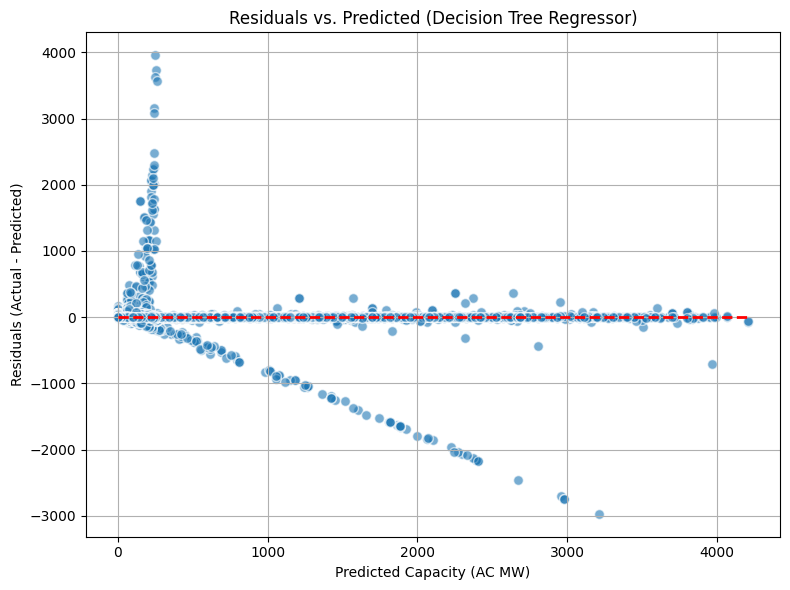

In [92]:
residuals_dt = y_test_reg - y_pred_dt_reg
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_dt_reg, residuals_dt, alpha=0.6, edgecolors='w', s=50)
plt.hlines(0, y_pred_dt_reg.min(), y_pred_dt_reg.max(), colors='r', linestyles='--', linewidth=2)
plt.xlabel("Predicted Capacity (AC MW)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted (Decision Tree Regressor)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [93]:
from sklearn.ensemble import RandomForestRegressor

model_rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_rf_reg = model_rf_reg.predict(X_test_reg_scaled)
print("Random Forest Regression MSE:", mean_squared_error(y_test_reg, y_pred_rf_reg))
print("Random Forest Regression R^2:", r2_score(y_test_reg, y_pred_rf_reg))


Random Forest Regression MSE: 6316.313352602306
Random Forest Regression R^2: 0.9773012656666399


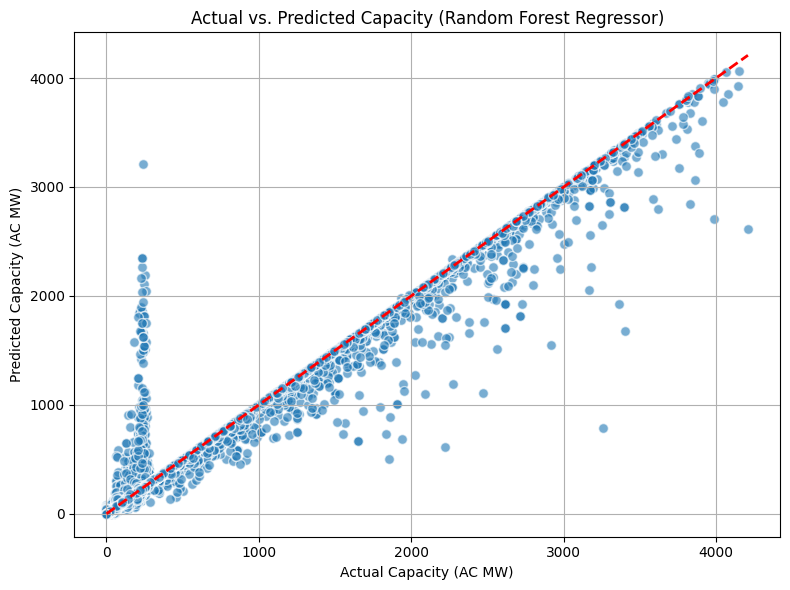

In [94]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.6, edgecolors='w', s=50)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', linewidth=2)
plt.xlabel("Actual Capacity (AC MW)")
plt.ylabel("Predicted Capacity (AC MW)")
plt.title("Actual vs. Predicted Capacity (Random Forest Regressor)")
plt.grid(True)
plt.tight_layout()
plt.show()

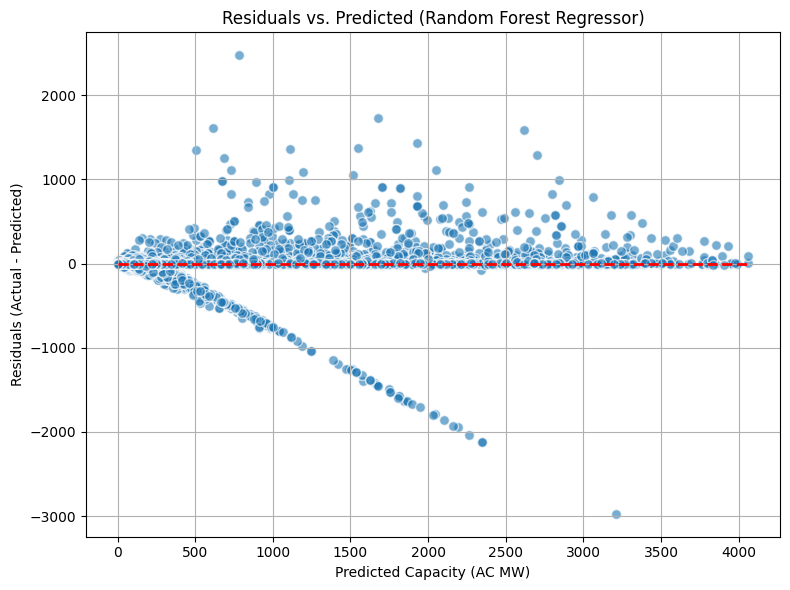

In [95]:
residuals_rf = y_test_reg - y_pred_rf_reg
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_rf_reg, residuals_rf, alpha=0.6, edgecolors='w', s=50)
plt.hlines(0, y_pred_rf_reg.min(), y_pred_rf_reg.max(), colors='r', linestyles='--', linewidth=2)
plt.xlabel("Predicted Capacity (AC MW)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted (Random Forest Regressor)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, r2_score

# --- Reshape for LSTM (requires 3D input: [samples, timesteps, features]) ---
X_train_lstm = X_train_reg_scaled.reshape((X_train_reg_scaled.shape[0], 1, X_train_reg_scaled.shape[1]))
X_test_lstm = X_test_reg_scaled.reshape((X_test_reg_scaled.shape[0], 1, X_test_reg_scaled.shape[1]))

# --- Build LSTM model for regression ---
model_lstm_reg = Sequential([
    LSTM(50, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dense(1)  # Single continuous output
])

model_lstm_reg.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
model_lstm_reg.summary()

# --- Train the model ---
history_lstm_reg = model_lstm_reg.fit(X_train_lstm, y_train_reg, epochs=20,
                                      validation_data=(X_test_lstm, y_test_reg), verbose=1)

# --- Predict and evaluate ---
y_pred_lstm_reg = model_lstm_reg.predict(X_test_lstm).flatten()

print("LSTM Regression MSE:", mean_squared_error(y_test_reg, y_pred_lstm_reg))
print("LSTM Regression R^2:", r2_score(y_test_reg, y_pred_lstm_reg))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 50)             │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,251 (43.95 KB)

 Trainable params: 11,251 (43.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 58730.2305 - val_loss: 36329.1992
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 32633.0801 - val_loss: 30237.0176
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 28472.3574 - val_loss: 27183.6660
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 25898.5039 - val_loss: 24571.5840
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 24068.1816 - val_loss: 22504.2383
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 22732.3633 - val_loss: 24154.0332
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 21766.8496 - val_loss: 21477.3496
Epoch 8/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 21114.5391 - val_loss: 24021.7480
Epoch 9/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 20326.9902 - val_loss: 18874.8125
Epoch 10/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - loss: 19672.2090 - val_loss: 18966.3477
Epoch 11/20
4500/4500 ━━━━━━━

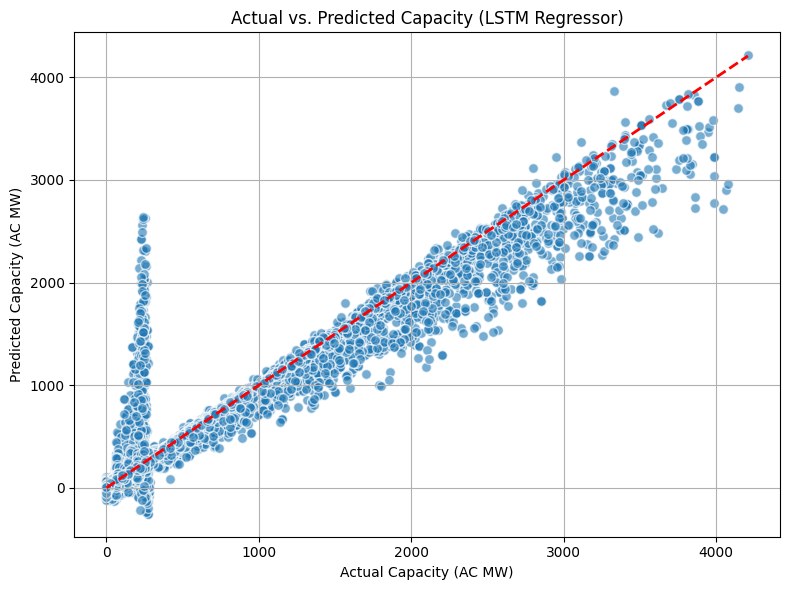

In [97]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_lstm_reg, alpha=0.6, edgecolors='w', s=50)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', linewidth=2)
plt.xlabel("Actual Capacity (AC MW)")
plt.ylabel("Predicted Capacity (AC MW)")
plt.title("Actual vs. Predicted Capacity (LSTM Regressor)")
plt.grid(True)
plt.tight_layout()
plt.show()


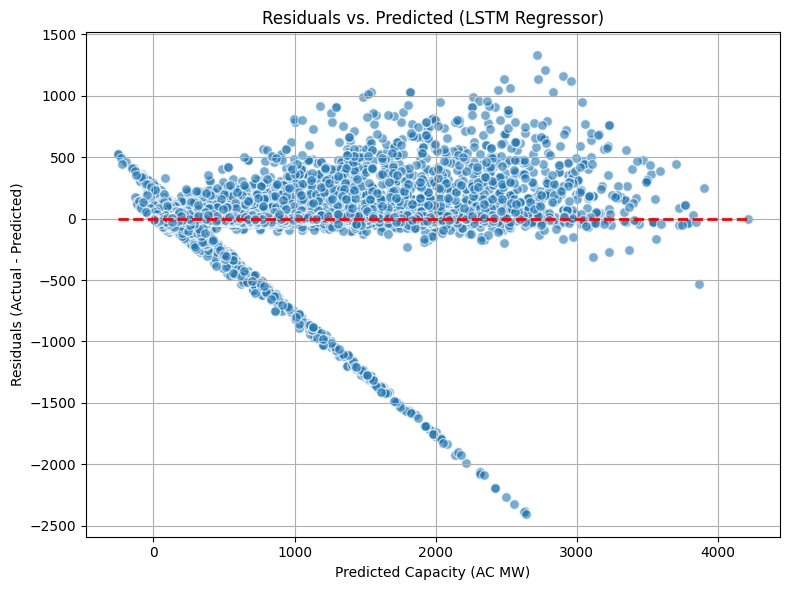

In [98]:
residuals_lstm = y_test_reg - y_pred_lstm_reg
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_lstm_reg, residuals_lstm, alpha=0.6, edgecolors='w', s=50)
plt.hlines(0, y_pred_lstm_reg.min(), y_pred_lstm_reg.max(), colors='r', linestyles='--', linewidth=2)
plt.xlabel("Predicted Capacity (AC MW)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs. Predicted (LSTM Regressor)")
plt.grid(True)
plt.tight_layout()
plt.show()


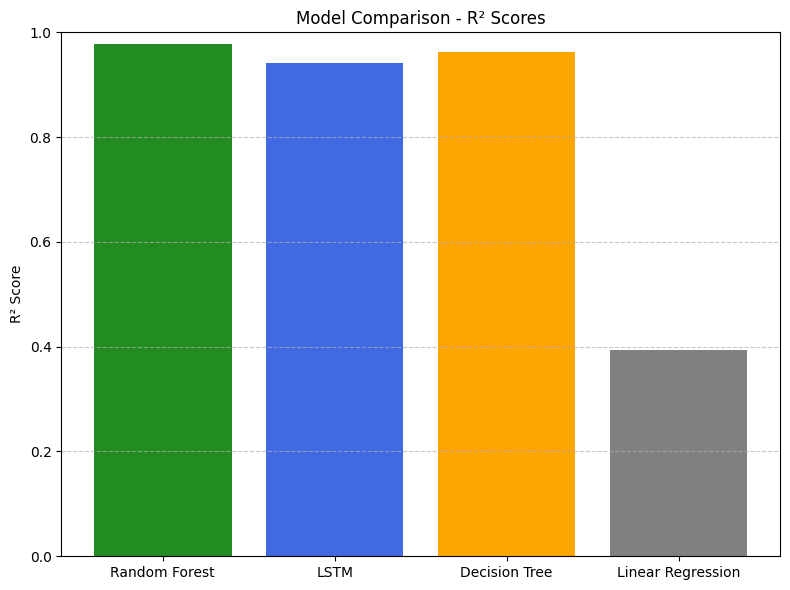

In [99]:
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score


r2_rf_reg = r2_score(y_test_reg, y_pred_rf_reg)
r2_lstm_reg = r2_score(y_test_reg, y_pred_lstm_reg)
r2_dt_reg = r2_score(y_test_reg, y_pred_dt_reg)
r2_lr_reg = r2_score(y_test_reg, y_pred_lr)

r2_scores = {
    'Random Forest': r2_rf_reg,
    'LSTM': r2_lstm_reg,
    'Decision Tree': r2_dt_reg,
    'Linear Regression': r2_lr_reg
}

# Plotting
plt.figure(figsize=(8, 6))
plt.bar(r2_scores.keys(), r2_scores.values(), color=['forestgreen', 'royalblue', 'orange', 'gray'])
plt.title("Model Comparison - R² Scores")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### For Consumption -

In [107]:
cons_df = pd.read_excel('US_Prod_and_Cons.xlsx', header=10)
# Drop the first row, which contains units like '(Trillion Btu)'
cons_df = cons_df.iloc[1:].reset_index(drop=True)
print("Initial Data:")
cons_df.head()

Initial Data:


,Month,Wood Energy Production,Biofuels Production,Total Biomass Energy Production,Total Renewable Energy Production,Hydroelectric Power Consumption,Geothermal Energy Consumption,Solar Energy Consumption,Wind Energy Consumption,Wood Energy Consumption,Waste Energy Consumption,Biofuels Consumption,Total Biomass Energy Consumption,Total Renewable Energy Consumption
0,1973-01-01,129.63,Not Available,129.787,219.839,89.562,0.49,Not Available,Not Available,129.63,0.157,Not Available,129.787,219.839
1,1973-02-01,117.194,Not Available,117.338,197.33,79.544,0.448,Not Available,Not Available,117.194,0.144,Not Available,117.338,197.33
2,1973-03-01,129.763,Not Available,129.938,218.686,88.284,0.464,Not Available,Not Available,129.763,0.176,Not Available,129.938,218.686
3,1973-04-01,125.462,Not Available,125.636,209.33,83.152,0.542,Not Available,Not Available,125.462,0.174,Not Available,125.636,209.33
4,1973-05-01,129.624,Not Available,129.834,215.982,85.643,0.505,Not Available,Not Available,129.624,0.21,Not Available,129.834,215.982


## Forecasting Using Arima

/tmp/ipykernel_1134/564034064.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cons_df[col] = cons_df[col].replace('Not Available', np.nan)



Data after setting datetime index and cleaning 'Not Available':


,Wood Energy Production,Biofuels Production,Total Biomass Energy Production,Total Renewable Energy Production,Hydroelectric Power Consumption,Geothermal Energy Consumption,Solar Energy Consumption,Wind Energy Consumption,Wood Energy Consumption,Waste Energy Consumption,Biofuels Consumption,Total Biomass Energy Consumption,Total Renewable Energy Consumption
Month,,,,,,,,,,,,,
1973-01-01,129.630,NaN,129.787,219.839,89.562,0.490,NaN,NaN,129.630,0.157,NaN,129.787,219.839
1973-02-01,117.194,NaN,117.338,197.330,79.544,0.448,NaN,NaN,117.194,0.144,NaN,117.338,197.330
1973-03-01,129.763,NaN,129.938,218.686,88.284,0.464,NaN,NaN,129.763,0.176,NaN,129.938,218.686
1973-04-01,125.462,NaN,125.636,209.330,83.152,0.542,NaN,NaN,125.462,0.174,NaN,125.636,209.330
1973-05-01,129.624,NaN,129.834,215.982,85.643,0.505,NaN,NaN,129.624,0.210,NaN,129.834,215.982


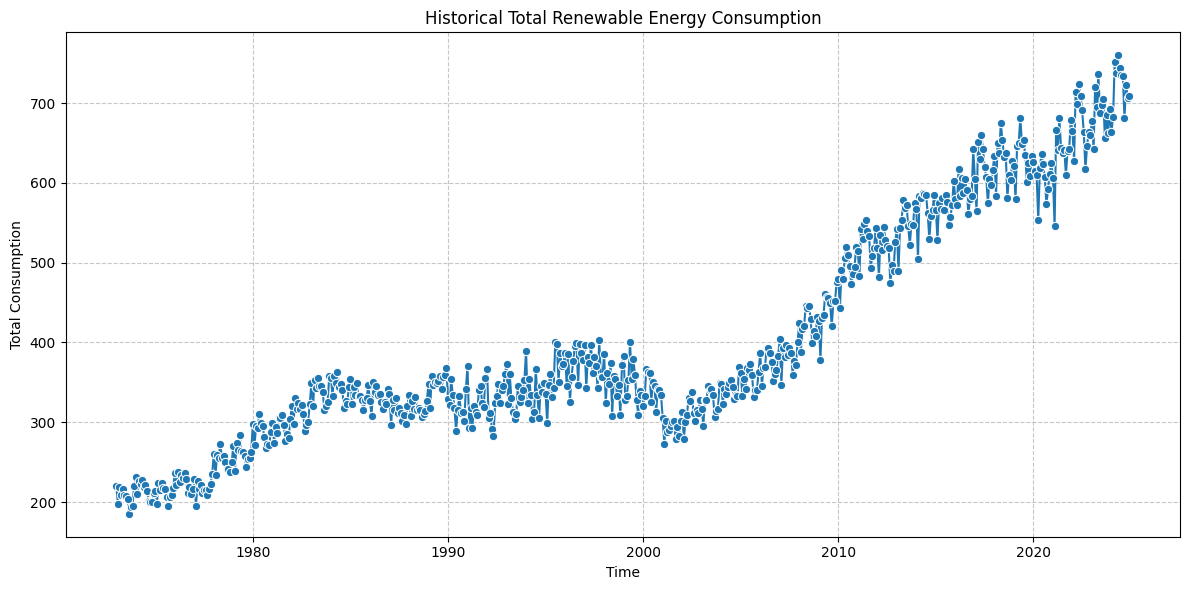

In [108]:
cons_df['Month'] = pd.to_datetime(cons_df['Month'])
cons_df = cons_df.set_index('Month')
cons_df.sort_index(inplace=True)

# Replace 'Not Available' with NaN and convert to numeric for the target column
# This also handles cases where other columns might have 'Not Available'
for col in cons_df.columns:
    if cons_df[col].dtype == 'object':
        cons_df[col] = cons_df[col].replace('Not Available', np.nan)
        cons_df[col] = pd.to_numeric(cons_df[col], errors='coerce')


print("\nData after setting datetime index and cleaning 'Not Available':")
display(cons_df.head())

# Visualize the Total Renewable Energy Consumption
plt.figure(figsize=(12, 6))
sns.lineplot(data=cons_df, x=cons_df.index, y="Total Renewable Energy Consumption", marker='o')
plt.title("Historical Total Renewable Energy Consumption")
plt.xlabel("Time")
plt.ylabel("Total Consumption")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [109]:
# Using ARIMA on Total Renewable Energy Consumption
series = cons_df["Total Renewable Energy Consumption"].dropna() # ARIMA requires no missing values

# Fit the ARIMA model
# (p,d,q) order parameters: p=AR order, d=differencing order, q=MA order
# These values can be optimized, but (1,1,1) is a common starting point for time series data
model = ARIMA(series, order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

# Forecast the next 12 periods (months in this case)
forecast_steps = 12
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_df = forecast.summary_frame()

# Create forecast index: assuming monthly frequency
last_date = series.index[-1]
forecast_index = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast_df.index = forecast_index

print("\nForecasted values:")
display(forecast_df[['mean', 'mean_ci_lower', 'mean_ci_upper']])

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                                       SARIMAX Results                                        
Dep. Variable:     Total Renewable Energy Consumption   No. Observations:                  624
Model:                                 ARIMA(1, 1, 1)   Log Likelihood               -2811.739
Date:                                Sat, 04 Jul 2026   AIC                           5629.478
Time:                                        15:06:36   BIC                           5642.782
Sample:                                    01-01-1973   HQIC                          5634.648
                                         - 12-01-2024                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2010      0.054      3.735      0.000       0.096       0.306
ma.

Total Renewable Energy Consumption,mean,mean_ci_lower,mean_ci_upper
2025-01-01,712.870399,669.630936,756.109861
2025-02-01,713.648057,666.376657,760.919456
2025-03-01,713.804348,664.431104,763.177591
2025-04-01,713.835758,662.708366,764.963150
2025-05-01,713.842071,661.067659,766.616484
2025-06-01,713.843340,659.481236,768.205444
2025-07-01,713.843595,657.940718,769.746472
2025-08-01,713.843646,656.441698,771.245594
2025-09-01,713.843657,654.980874,772.706439
2025-10-01,713.843659,653.555442,774.131875


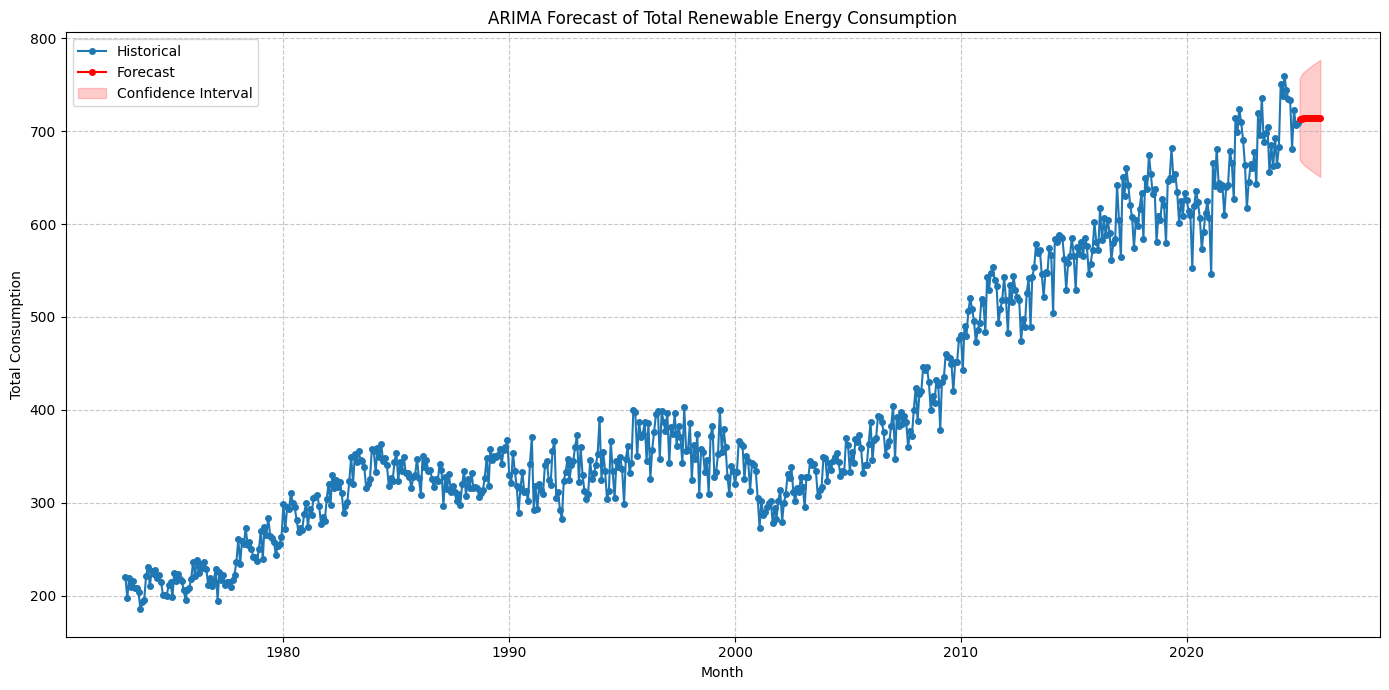

In [110]:
plt.figure(figsize=(14, 7))
plt.plot(series.index, series, label='Historical', marker='o', markersize=4)
plt.plot(forecast_df.index, forecast_df['mean'], label='Forecast', marker='o', markersize=4, color='red')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'],
                 color='red', alpha=0.2, label='Confidence Interval')

plt.title("ARIMA Forecast of Total Renewable Energy Consumption")
plt.xlabel("Month")
plt.ylabel("Total Consumption")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()